In [1]:
# Cell 1: Install Required Packages
!pip install kagglehub duckdb shap xgboost -q

import kagglehub
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ All packages installed and imported!")

✅ All packages installed and imported!


In [2]:
# Cell 2: Download Dataset from Kaggle
print("Downloading US Accidents dataset from Kaggle...")
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print(f"✅ Dataset downloaded to: {path}")

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"Found CSV files: {csv_files}")

data_path = os.path.join(path, csv_files[0])
print(f"Using file: {data_path}")

100%|██████████| 653M/653M [00:16<00:00, 40.9MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13
Found CSV files: ['US_Accidents_March23.csv']
Using file: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13/US_Accidents_March23.csv


In [3]:
# Cell 3: Load Sample Data Using DuckDB
print("Loading sample data with DuckDB...")

con = duckdb.connect()
query = f"""
    SELECT * FROM read_csv_auto('{data_path}')
    USING SAMPLE 100000 ROWS
"""
df = con.execute(query).df()
con.close()

print(f"✅ Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nData Types:")
print(df.dtypes.value_counts())
display(df.head())

Loading sample data with DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Loaded 100,000 rows × 46 columns
Memory usage: 113.25 MB

Data Types:
object            19
bool              13
float64           10
datetime64[us]     3
int64              1
Name: count, dtype: int64


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-75386,Source2,3,2016-11-26 23:16:54,2016-11-26 23:46:29,33.960133,-118.280518,None,None,0.01,...,False,True,True,False,False,False,Night,Night,Night,Night
1,A-126282,Source2,2,2016-11-06 14:23:54,2016-11-06 15:23:34,25.769794,-80.324600,None,None,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day
2,A-30795,Source2,3,2016-09-09 11:39:57,2016-09-09 12:09:57,37.698196,-121.934677,None,None,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-1790505,Source2,2,2019-10-31 22:19:44,2019-10-31 23:34:44,32.970734,-96.871094,None,None,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
4,A-1545052,Source2,2,2020-04-03 08:58:46,2020-04-03 09:59:33,34.520802,-82.650879,None,None,0.00,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
# Cell 5: PROPER Preprocessing (FIXED DATA LEAKAGE)
print("="*70)
print("PREPROCESSING (FIXED)")
print("="*70)

print("\n🎯 Identifying target column...")
if 'Severity' in df.columns:
    target_col = 'Severity'
else:
    target_col = df.columns[-1]

print(f"   Target column: '{target_col}'")
print(f"   Target distribution:\n{df[target_col].value_counts().sort_index()}")

# Drop non-predictive columns
cols_to_drop = []
id_cols = ['ID', 'id', 'Index']
cols_to_drop += [c for c in id_cols if c in df.columns]
text_cols = ['Description', 'description']
cols_to_drop += [c for c in text_cols if c in df.columns]

print(f"\n🗑️  Dropping non-predictive columns: {cols_to_drop}")
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# DateTime conversion
print("\n🔄 Converting DateTime columns...")
datetime_cols = df.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns.tolist()

for col in datetime_cols:
    print(f"   Processing: {col}")
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
    df[f'{col}_hour'] = df[col].dt.hour
    df[f'{col}_dayofweek'] = df[col].dt.dayofweek
    df = df.drop(columns=[col])

print(f"   ✅ Converted {len(datetime_cols)} datetime columns")

# Missing values
print("\n🔄 Handling missing values...")
missing_pct = df.isnull().sum() / len(df)
high_missing_cols = missing_pct[missing_pct > 0.5].index.tolist()
if high_missing_cols:
    print(f"   Dropping {len(high_missing_cols)} columns with >50% missing")
    df = df.drop(columns=high_missing_cols)

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna('Unknown', inplace=True)
        elif df[col].dtype == 'bool':
            df[col].fillna(False, inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print(f"   ✅ Missing values handled")

# Separate features and target
print("\n🔄 Separating features and target...")
y = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"   Target classes: {sorted(y.unique())}")

# Encode categoricals
print("\n🔄 Encoding categorical features...")
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"   Encoded {len(categorical_cols)} categorical columns")

# Convert booleans
bool_cols = X.select_dtypes(include=['bool']).columns.tolist()
for col in bool_cols:
    X[col] = X[col].astype(int)
print(f"   Converted {len(bool_cols)} boolean columns")

# Encode target
target_encoder = None
if y.dtype == 'object':
    target_encoder = LabelEncoder()
    y = pd.Series(target_encoder.fit_transform(y), index=y.index)
    print(f"\n🎯 Target encoded: {target_encoder.classes_}")
else:
    y = y.astype(int)
    print(f"\n🎯 Target classes: {sorted(y.unique())}")

# Final validation
print("\n📊 Final validation:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

non_numeric = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f"   ⚠️  Converting {len(non_numeric)} non-numeric columns")
    for col in non_numeric:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

if target_col in X.columns:
    print(f"   ⚠️  REMOVING {target_col} from features (was leaking!)")
    X = X.drop(columns=[target_col])

print(f"\n✅ Preprocessing complete!")
print(f"   Final features: {X.shape[1]}")
print(f"   Target distribution:\n{y.value_counts().sort_index()}")

PREPROCESSING (FIXED)

🎯 Identifying target column...
   Target column: 'Severity'
   Target distribution:
Severity
1      481
2    68690
3    29368
4     1461
Name: count, dtype: int64

🗑️  Dropping non-predictive columns: ['ID', 'Description']

🔄 Converting DateTime columns...
   Processing: Start_Time
   Processing: End_Time
   Processing: Weather_Timestamp
   ✅ Converted 3 datetime columns

🔄 Handling missing values...
   Dropping 4 columns with >50% missing
   ✅ Missing values handled

🔄 Separating features and target...
   Features (X): (100000, 51)
   Target (y): (100000,)
   Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

🔄 Encoding categorical features...
   Encoded 15 categorical columns
   Converted 13 boolean columns

🎯 Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

📊 Final validation:
   X shape: (100000, 51)
   y shape: (100000,)

✅ Preprocessing complete!
   Final features: 51
   Target distribution:
Severity
1      481
2    6

In [5]:
# Cell 6: Train-Test Split and DUAL Model Training
print("="*70)
print("MODEL TRAINING (Decision Tree + XGBoost)")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Training set: {len(X_train):,} samples")
print(f"📊 Testing set:  {len(X_test):,} samples")

if 'Severity' in X_train.columns:
    X_train = X_train.drop(columns=['Severity'])
    X_test = X_test.drop(columns=['Severity'])

# ─── Model 1: Decision Tree (Baseline) ───
print("\n" + "─"*40)
print("🌳 MODEL 1: Decision Tree (Baseline)")
print("─"*40)

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_model.predict(X_test))

print(f"   Training Accuracy: {dt_train_acc*100:.2f}%")
print(f"   Testing Accuracy:  {dt_test_acc*100:.2f}%")
print(f"   Gap: {(dt_train_acc - dt_test_acc)*100:.1f}%")

print("\n📋 Decision Tree Classification Report:")
print(classification_report(y_test, dt_model.predict(X_test)))

# ─── Model 2: XGBoost (Strong Tabular Model) ───
print("─"*40)
print("🚀 MODEL 2: XGBoost (Strong Model)")
print("─"*40)

# Remap labels to 0-based if needed (XGBoost requirement)
unique_classes = sorted(y_train.unique())
n_classes = len(unique_classes)
class_map = {c: i for i, c in enumerate(unique_classes)}
class_map_inv = {i: c for c, i in class_map.items()}

y_train_xgb = y_train.map(class_map)
y_test_xgb = y_test.map(class_map)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',          # Fast for large data
    n_jobs=-1
)
xgb_model.fit(X_train, y_train_xgb, verbose=False)

xgb_train_acc = accuracy_score(y_train_xgb, xgb_model.predict(X_train))
xgb_test_acc = accuracy_score(y_test_xgb, xgb_model.predict(X_test))

print(f"   Training Accuracy: {xgb_train_acc*100:.2f}%")
print(f"   Testing Accuracy:  {xgb_test_acc*100:.2f}%")
print(f"   Gap: {(xgb_train_acc - xgb_test_acc)*100:.1f}%")

# Map predictions back for classification report
y_pred_xgb = pd.Series(xgb_model.predict(X_test)).map(class_map_inv)

print("\n📋 XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# ─── Model Comparison ───
print("="*70)
print("📊 MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'XGBoost'],
    'Train Accuracy': [f"{dt_train_acc*100:.2f}%", f"{xgb_train_acc*100:.2f}%"],
    'Test Accuracy': [f"{dt_test_acc*100:.2f}%", f"{xgb_test_acc*100:.2f}%"],
    'Overfit Gap': [f"{(dt_train_acc-dt_test_acc)*100:.1f}%", f"{(xgb_train_acc-xgb_test_acc)*100:.1f}%"]
})
display(comparison_df)

# Select best model for SHAP analysis
if xgb_test_acc >= dt_test_acc:
    best_model = xgb_model
    best_model_name = "XGBoost"
    best_test_acc = xgb_test_acc
    use_xgb_labels = True
    print(f"\n🏆 Best Model: XGBoost ({xgb_test_acc*100:.2f}%)")
else:
    best_model = dt_model
    best_model_name = "Decision Tree"
    best_test_acc = dt_test_acc
    use_xgb_labels = False
    print(f"\n🏆 Best Model: Decision Tree ({dt_test_acc*100:.2f}%)")

# Keep dt_model reference for backward compat
model = best_model
test_accuracy = best_test_acc

MODEL TRAINING (Decision Tree + XGBoost)

📊 Training set: 80,000 samples
📊 Testing set:  20,000 samples

────────────────────────────────────────
🌳 MODEL 1: Decision Tree (Baseline)
────────────────────────────────────────
   Training Accuracy: 88.40%
   Testing Accuracy:  87.39%
   Gap: 1.0%

📋 Decision Tree Classification Report:
              precision    recall  f1-score   support

           1       0.47      0.28      0.35        96
           2       0.88      0.95      0.91     13738
           3       0.87      0.74      0.80      5874
           4       0.51      0.18      0.27       292

    accuracy                           0.87     20000
   macro avg       0.68      0.54      0.58     20000
weighted avg       0.87      0.87      0.87     20000

────────────────────────────────────────
🚀 MODEL 2: XGBoost (Strong Model)
────────────────────────────────────────
   Training Accuracy: 95.99%
   Testing Accuracy:  90.49%
   Gap: 5.5%

📋 XGBoost Classification Report:
          

,Model,Train Accuracy,Test Accuracy,Overfit Gap
0,Decision Tree,88.40%,87.39%,1.0%
1,XGBoost,95.99%,90.49%,5.5%



🏆 Best Model: XGBoost (90.49%)


In [6]:
# Cell 7: SHAP Explainer Initialization (Using Best Model)
print("="*70)
print(f"SHAP ANALYSIS (using {best_model_name})")
print("="*70)

print(f"\n🔄 Initializing SHAP TreeExplainer for {best_model_name}...")
explainer = shap.TreeExplainer(best_model)

n_shap_samples = min(200, len(X_test))
X_shap = X_test.sample(n=n_shap_samples, random_state=42)

print(f"🔄 Calculating SHAP values for {n_shap_samples} samples...")
shap_values = explainer.shap_values(X_shap)

print("✅ SHAP values calculated!")

if isinstance(shap_values, list):
    print(f"   Multi-class output: {len(shap_values)} classes")
    print(f"   Shape per class: {shap_values[0].shape}")
elif isinstance(shap_values, np.ndarray):
    print(f"   Shape: {shap_values.shape}")
    print(f"   Dimensions: {len(shap_values.shape)}D")

SHAP ANALYSIS (using XGBoost)

🔄 Initializing SHAP TreeExplainer for XGBoost...
🔄 Calculating SHAP values for 200 samples...
✅ SHAP values calculated!
   Shape: (200, 51, 4)
   Dimensions: 3D


SHAP SUMMARY PLOT


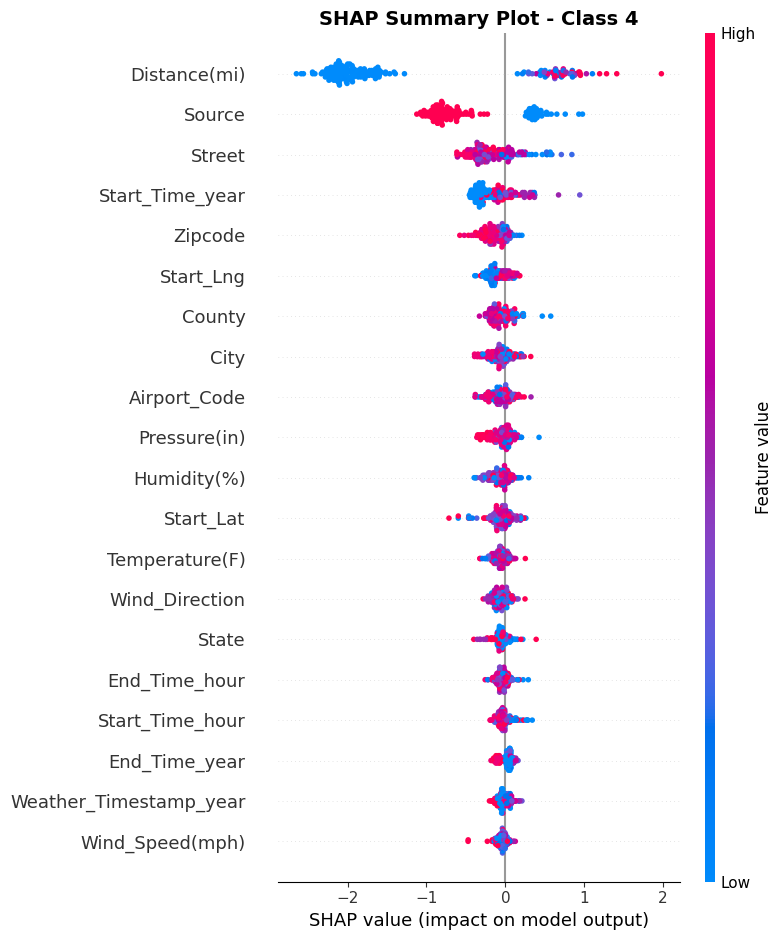


✅ Summary plot shows:
   • Most important features (top to bottom)
   • Impact direction (red = high value, blue = low value)
   • SHAP value magnitude (horizontal spread)


In [7]:
# Cell 8: SHAP Summary Plot (Beeswarm)
print("="*70)
print("SHAP SUMMARY PLOT")
print("="*70)

plt.figure(figsize=(12, 8))

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_shap, show=False)
    plt.title('SHAP Summary Plot - Class 0', fontsize=14, fontweight='bold')
elif len(shap_values.shape) == 3:
    # 3D: pick the most severe class (last class)
    class_to_show = shap_values.shape[2] - 1
    shap.summary_plot(shap_values[:, :, class_to_show], X_shap, show=False)
    plt.title(f'SHAP Summary Plot - Class {class_map_inv.get(class_to_show, class_to_show)}',
              fontsize=14, fontweight='bold')
else:
    shap.summary_plot(shap_values, X_shap, show=False)
    plt.title('SHAP Summary Plot - Feature Impact', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Summary plot shows:")
print("   • Most important features (top to bottom)")
print("   • Impact direction (red = high value, blue = low value)")
print("   • SHAP value magnitude (horizontal spread)")

SHAP FEATURE IMPORTANCE


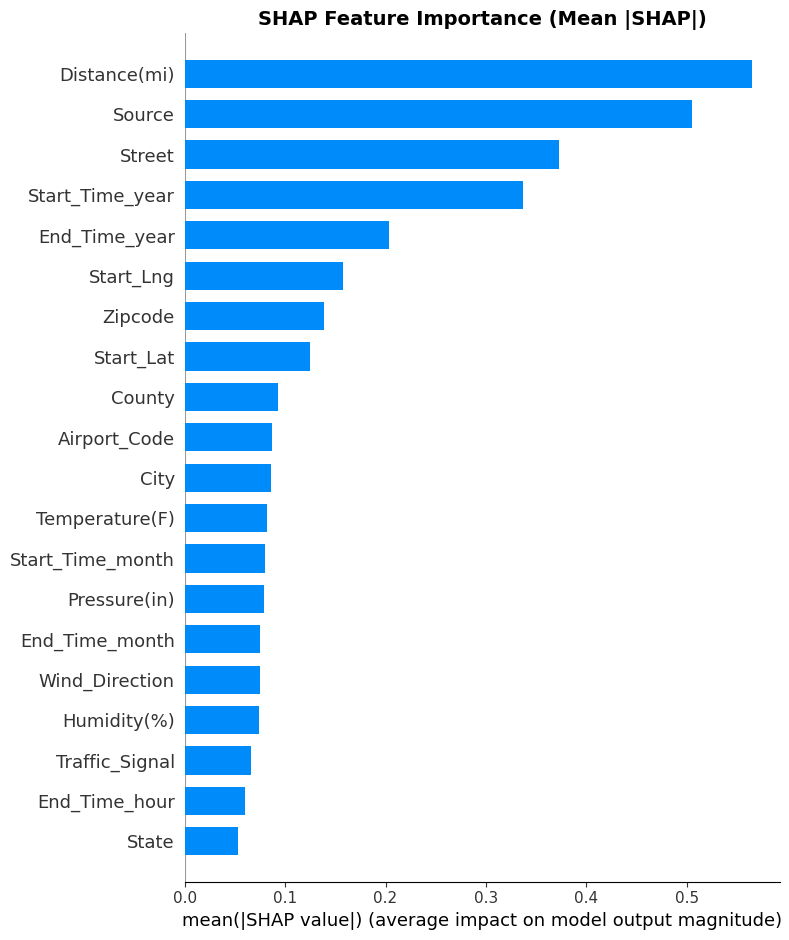


🔝 Top 10 Most Important Features:


,Feature,Importance
3,Distance(mi),0.564405
0,Source,0.505403
4,Street,0.372870
36,Start_Time_year,0.336842
41,End_Time_year,0.203361
2,Start_Lng,0.157581
8,Zipcode,0.138585
1,Start_Lat,0.124950
6,County,0.092755
11,Airport_Code,0.086593


In [8]:
# Cell 9: SHAP Feature Importance Bar Plot
print("="*70)
print("SHAP FEATURE IMPORTANCE")
print("="*70)

plt.figure(figsize=(10, 8))

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_shap, plot_type="bar", show=False)
elif len(shap_values.shape) == 3:
    shap_2d = np.abs(shap_values).mean(axis=2)
    shap.summary_plot(shap_2d, X_shap, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)

plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top features table
if isinstance(shap_values, list):
    mean_abs_shap = np.abs(np.array(shap_values)).mean(axis=(0, 1))
elif len(shap_values.shape) == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_abs_shap
}).sort_values('Importance', ascending=False)

print("\n🔝 Top 10 Most Important Features:")
display(feature_importance_df.head(10))

SHAP WATERFALL PLOT - INDIVIDUAL PREDICTION

📍 Explaining sample index: 0


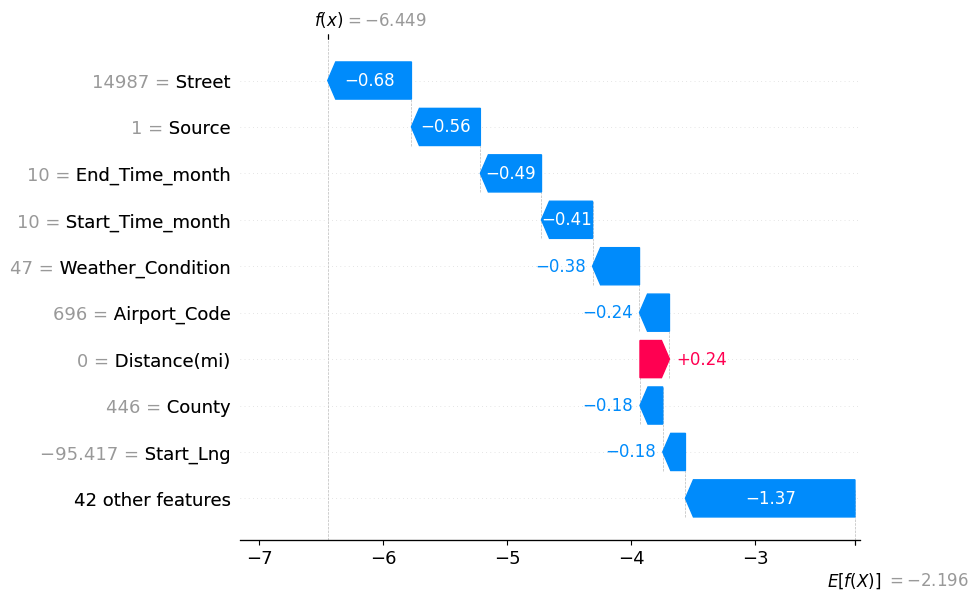


✅ Waterfall plot shows:
   • How each feature pushes prediction up (red) or down (blue)
   • Starting from base value to final prediction


In [10]:
# Cell 10: SHAP Waterfall Plot (Single Prediction)
print("="*70)
print("SHAP WATERFALL PLOT - INDIVIDUAL PREDICTION")
print("="*70)

sample_idx = 0
print(f"\n📍 Explaining sample index: {sample_idx}")

# Helper to safely extract a single base value
def get_base_value(expected_value, class_idx=0):
    """Extract a single float base value from any expected_value format."""
    if isinstance(expected_value, (list, np.ndarray)):
        return float(expected_value[class_idx])
    else:
        return float(expected_value)

if isinstance(shap_values, list):
    n_classes = len(shap_values)
    class_idx = 0
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[class_idx][sample_idx],
            base_values=get_base_value(explainer.expected_value, class_idx),
            data=X_shap.iloc[sample_idx].values,
            feature_names=X.columns.tolist()
        )
    )
elif len(shap_values.shape) == 3:
    class_idx = 0
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx, :, class_idx],
            base_values=get_base_value(explainer.expected_value, class_idx),
            data=X_shap.iloc[sample_idx].values,
            feature_names=X.columns.tolist()
        )
    )
else:
    # 2D array: binary or regression
    # For binary, expected_value might be a list of 2 — use class 1
    if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
        bv = get_base_value(explainer.expected_value, 1)
    else:
        bv = get_base_value(explainer.expected_value)

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=bv,
            data=X_shap.iloc[sample_idx].values,
            feature_names=X.columns.tolist()
        )
    )

print("\n✅ Waterfall plot shows:")
print("   • How each feature pushes prediction up (red) or down (blue)")
print("   • Starting from base value to final prediction")

In [11]:
# Cell 11: Accident Cause Analysis (NEW)
print("="*70)
print("🔍 ACCIDENT CAUSE ANALYSIS")
print("="*70)

# ─── Top 10 Accident Factors ───
print("\n📊 TOP 10 MOST INFLUENTIAL ACCIDENT FACTORS:")
print("─"*50)

for rank, (_, row) in enumerate(feature_importance_df.head(10).iterrows(), 1):
    bar = "█" * int(row['Importance'] / feature_importance_df['Importance'].max() * 30)
    print(f"   {rank:2d}. {row['Feature']:<30} {row['Importance']:.4f}  {bar}")

# ─── Context-Based Cause Patterns ───
print("\n\n📊 CONTEXT-BASED ACCIDENT CAUSE PATTERNS:")
print("─"*50)

# Analyze SHAP values per feature to discover patterns
feature_names = X.columns.tolist()

if isinstance(shap_values, list):
    shap_matrix = shap_values[0]   # Use first class
elif len(shap_values.shape) == 3:
    # Use highest severity class
    shap_matrix = shap_values[:, :, -1]
else:
    shap_matrix = shap_values

# Find features where high values increase severity
print("\n🔴 Features where HIGH values INCREASE severity:")
for i, fname in enumerate(feature_names):
    feature_vals = X_shap.iloc[:, i].values
    shap_col = shap_matrix[:, i]
    # Correlation between feature value and SHAP value
    if np.std(feature_vals) > 0 and np.std(shap_col) > 0:
        corr = np.corrcoef(feature_vals, shap_col)[0, 1]
        if corr > 0.15 and np.abs(shap_col).mean() > 0.01:
            print(f"   ↑ {fname}: correlation = {corr:.3f} (higher value → higher severity)")

print("\n🔵 Features where HIGH values DECREASE severity:")
for i, fname in enumerate(feature_names):
    feature_vals = X_shap.iloc[:, i].values
    shap_col = shap_matrix[:, i]
    if np.std(feature_vals) > 0 and np.std(shap_col) > 0:
        corr = np.corrcoef(feature_vals, shap_col)[0, 1]
        if corr < -0.15 and np.abs(shap_col).mean() > 0.01:
            print(f"   ↓ {fname}: correlation = {corr:.3f} (higher value → lower severity)")

print("\n✅ Cause analysis complete!")

🔍 ACCIDENT CAUSE ANALYSIS

📊 TOP 10 MOST INFLUENTIAL ACCIDENT FACTORS:
──────────────────────────────────────────────────
    1. Distance(mi)                   0.5644  ██████████████████████████████
    2. Source                         0.5054  ██████████████████████████
    3. Street                         0.3729  ███████████████████
    4. Start_Time_year                0.3368  █████████████████
    5. End_Time_year                  0.2034  ██████████
    6. Start_Lng                      0.1576  ████████
    7. Zipcode                        0.1386  ███████
    8. Start_Lat                      0.1250  ██████
    9. County                         0.0928  ████
   10. Airport_Code                   0.0866  ████


📊 CONTEXT-BASED ACCIDENT CAUSE PATTERNS:
──────────────────────────────────────────────────

🔴 Features where HIGH values INCREASE severity:
   ↑ Start_Lng: correlation = 0.644 (higher value → higher severity)
   ↑ Distance(mi): correlation = 0.683 (higher value → higher sev

🔗 SHAP FEATURE INTERACTION ANALYSIS

🔄 Computing SHAP interaction values for 50 samples...
   (This reveals feature PAIRS that jointly affect severity)
✅ Interaction values computed!

🔝 TOP 15 FEATURE INTERACTION PAIRS:
─────────────────────────────────────────────────────────────────
   Rank  Feature 1                 Feature 2                 Strength  
─────────────────────────────────────────────────────────────────
   1     Source                    Distance(mi)              0.0992 ████████████████████
   2     Source                    Start_Time_year           0.0807 ████████████████
   3     Source                    Street                    0.0696 ██████████████
   4     Distance(mi)              Street                    0.0684 █████████████
   5     Distance(mi)              Start_Time_year           0.0459 █████████
   6     Start_Lat                 Distance(mi)              0.0434 ████████
   7     Distance(mi)              End_Time_year             0.0429 ████████
   8 

<Figure size 1000x600 with 0 Axes>

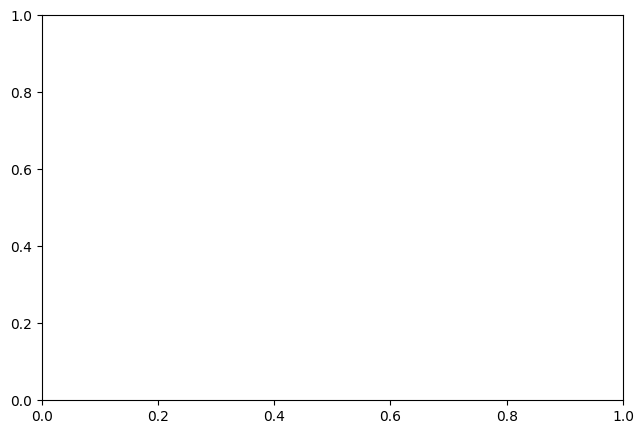

<Figure size 800x500 with 0 Axes>

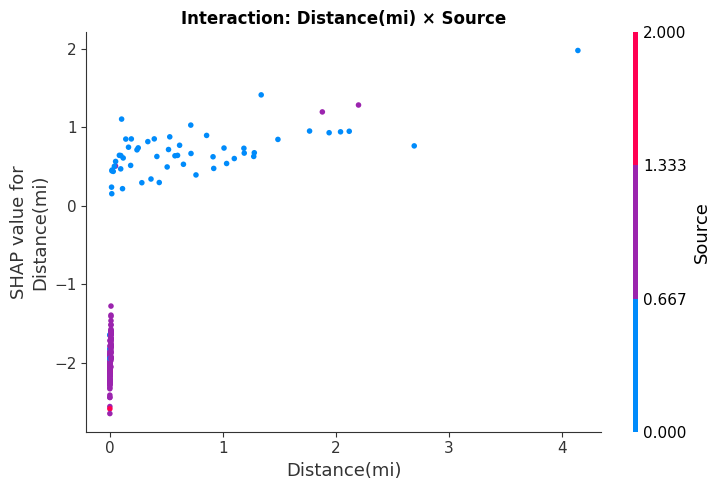

<Figure size 800x500 with 0 Axes>

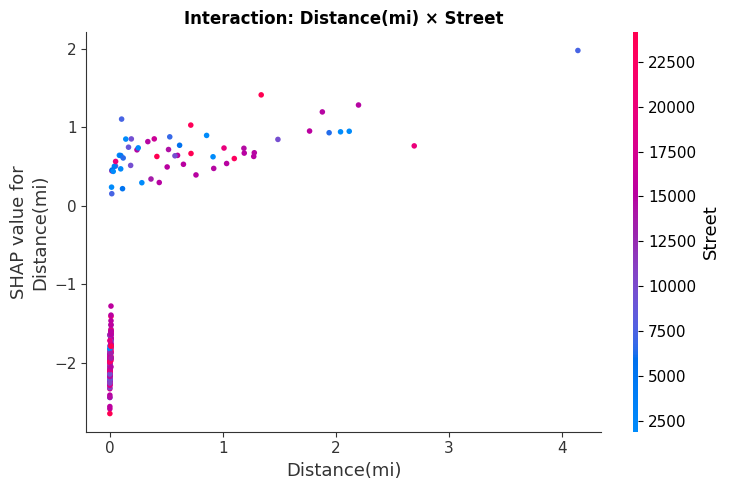

<Figure size 800x500 with 0 Axes>

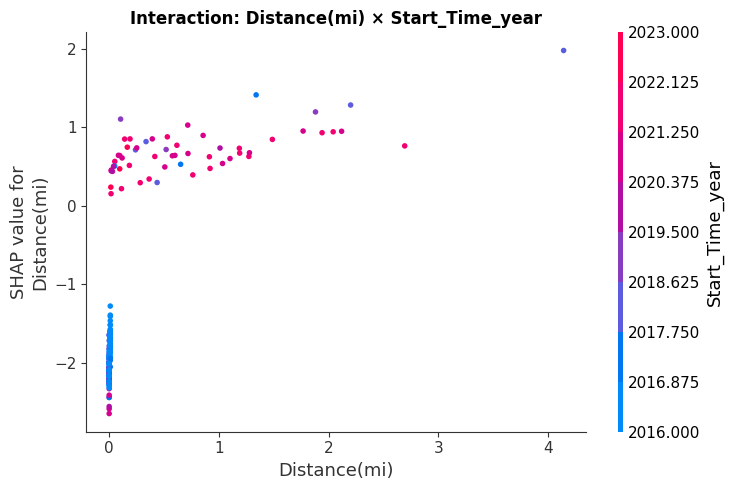

<Figure size 800x500 with 0 Axes>

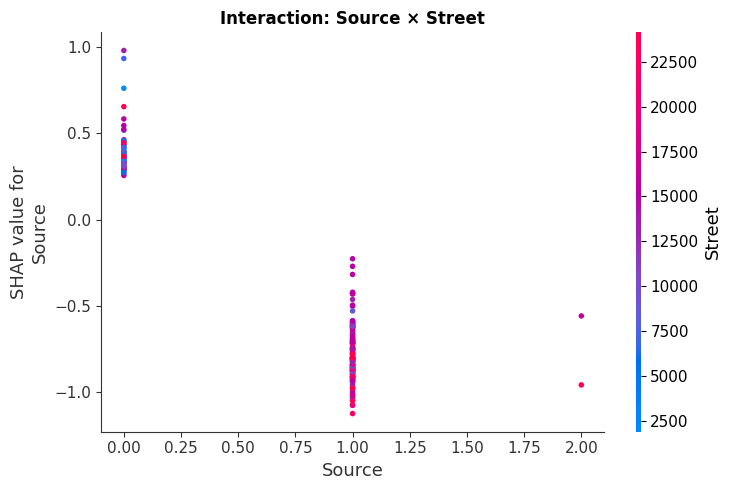

<Figure size 800x500 with 0 Axes>

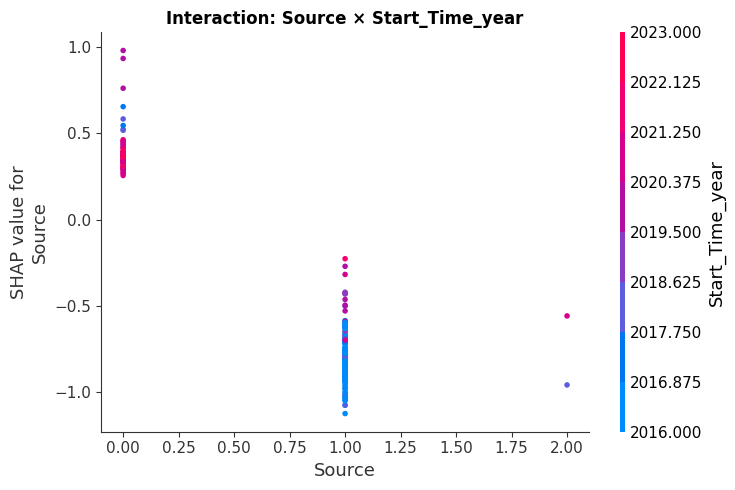

<Figure size 800x500 with 0 Axes>

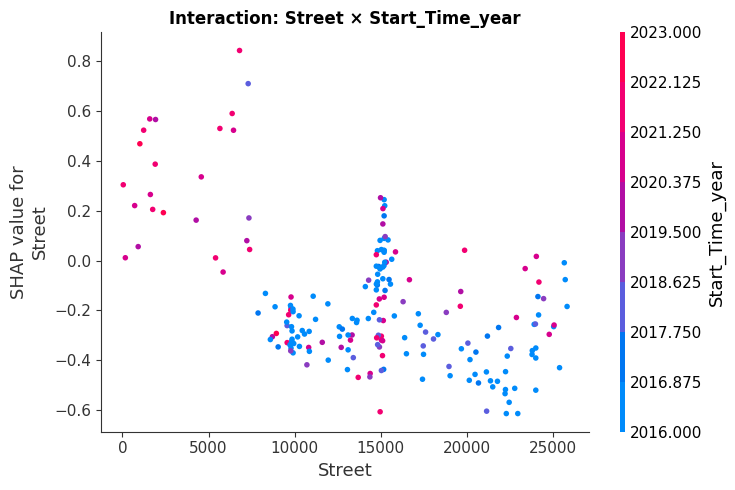


✅ Interaction analysis complete!


In [12]:
# Cell 12: SHAP Interaction Analysis (NEW - NOVEL)
print("="*70)
print("🔗 SHAP FEATURE INTERACTION ANALYSIS")
print("="*70)

# Use a smaller sample for interaction values (computationally expensive)
n_interaction_samples = min(30, len(X_shap))
X_interact = X_shap.iloc[:n_interaction_samples]

print(f"\n🔄 Computing SHAP interaction values for {n_interaction_samples} samples...")
print("   (This reveals feature PAIRS that jointly affect severity)")

try:
    shap_interaction = explainer.shap_interaction_values(X_interact)
    print("✅ Interaction values computed!")

    # Handle multi-class: pick the highest severity class
    if isinstance(shap_interaction, list):
        interact_matrix = shap_interaction[-1]  # Last class = highest severity
    elif len(shap_interaction.shape) == 4:
        interact_matrix = shap_interaction[:, :, :, -1]
    else:
        interact_matrix = shap_interaction

    # interact_matrix shape: (n_samples, n_features, n_features)
    # Compute mean absolute interaction strength (off-diagonal)
    n_features = interact_matrix.shape[1]
    interaction_strength = np.abs(interact_matrix).mean(axis=0)

    # Zero out diagonal (self-interactions)
    np.fill_diagonal(interaction_strength, 0)

    # Find top interaction pairs
    interaction_pairs = []
    for i in range(n_features):
        for j in range(i+1, n_features):
            interaction_pairs.append({
                'Feature_1': feature_names[i],
                'Feature_2': feature_names[j],
                'Interaction_Strength': interaction_strength[i, j]
            })

    interact_df = pd.DataFrame(interaction_pairs).sort_values(
        'Interaction_Strength', ascending=False
    )

    print("\n🔝 TOP 15 FEATURE INTERACTION PAIRS:")
    print("─"*65)
    print(f"   {'Rank':<5} {'Feature 1':<25} {'Feature 2':<25} {'Strength':<10}")
    print("─"*65)

    for rank, (_, row) in enumerate(interact_df.head(15).iterrows(), 1):
        bar = "█" * int(row['Interaction_Strength'] / interact_df['Interaction_Strength'].max() * 20)
        print(f"   {rank:<5} {row['Feature_1']:<25} {row['Feature_2']:<25} "
              f"{row['Interaction_Strength']:.4f} {bar}")

    # ─── Interpret key patterns ───
    print("\n\n🧠 DISCOVERED ACCIDENT PATTERNS:")
    print("─"*65)
    for rank, (_, row) in enumerate(interact_df.head(5).iterrows(), 1):
        f1, f2 = row['Feature_1'], row['Feature_2']
        strength = row['Interaction_Strength']
        print(f"\n   Pattern {rank}: {f1} × {f2}")
        print(f"   Interaction Strength: {strength:.4f}")
        print(f"   → These two features JOINTLY affect accident severity")
        print(f"   → Their combined effect differs from their individual effects")

    # SHAP interaction plot for top pair
    print("\n\n📊 SHAP Interaction Dependence Plot (Top Pair):")
    top_f1_idx = feature_names.index(interact_df.iloc[0]['Feature_1'])
    top_f2_idx = feature_names.index(interact_df.iloc[0]['Feature_2'])

    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        top_f1_idx,
        interact_matrix,
        X_interact,
        interaction_index=top_f2_idx,
        show=False
    )
    plt.title(f'SHAP Interaction: {interact_df.iloc[0]["Feature_1"]} × '
              f'{interact_df.iloc[0]["Feature_2"]}',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️  Interaction analysis error: {e}")
    print("   Falling back to approximate interaction analysis...")

    # Fallback: use SHAP dependence plots for likely interactions
    important_features = feature_importance_df.head(6)['Feature'].tolist()
    print(f"\n   Analyzing interactions among top features: {important_features}")

    for i in range(min(3, len(important_features))):
        for j in range(i+1, min(4, len(important_features))):
            f1, f2 = important_features[i], important_features[j]
            plt.figure(figsize=(8, 5))
            shap.dependence_plot(
                f1, shap_matrix, X_shap,
                interaction_index=f2, show=False
            )
            plt.title(f'Interaction: {f1} × {f2}', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

print("\n✅ Interaction analysis complete!")

🔍 CONTEXT-BASED ACCIDENT CAUSE ANALYSIS
Discovering WHY accidents happen in different situations...

🌧️  ACCIDENT SEVERITY BY WEATHER CONDITION:
───────────────────────────────────────────────────────
    1. Scattered Clouds                    Severity: 2.44  Count:  4458  ███████████████
    2. Overcast                            Severity: 2.42  Count:  7946  ███████████████
    3. Haze                                Severity: 2.42  Count:  1513  ███████████████
    4. Clear                               Severity: 2.42  Count: 30158  ███████████████
    5. Light Drizzle                       Severity: 2.39  Count:   184  ██████████████
    6. Partly Cloudy                       Severity: 2.35  Count:  8903  ██████████████
    7. Rain                                Severity: 2.32  Count:   914  ██████████████
    8. Light Rain                          Severity: 2.32  Count:  3768  ██████████████
    9. Mostly Cloudy                       Severity: 2.32  Count: 11626  ██████████████
   

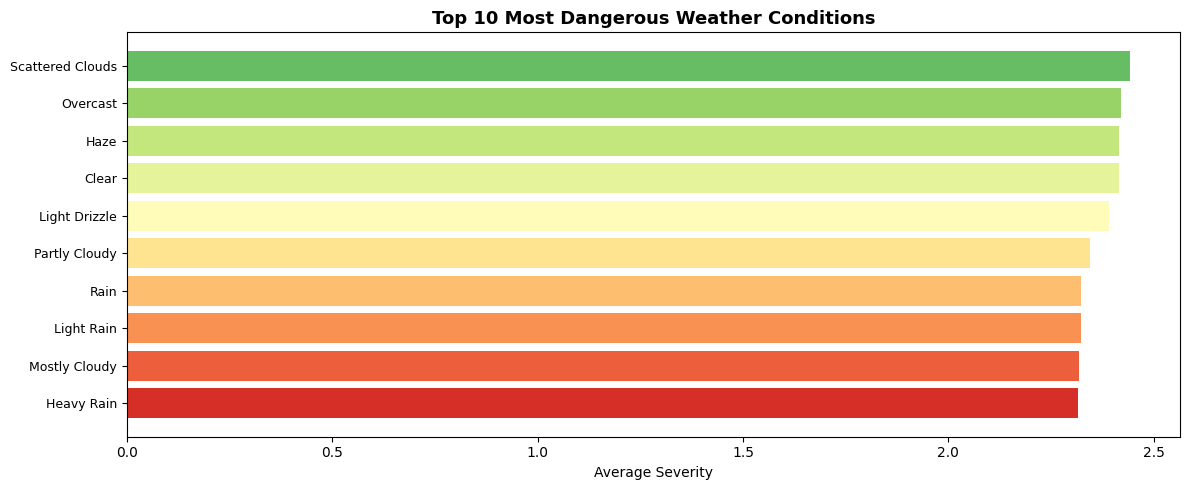



📅 ACCIDENT SEVERITY BY DAY OF WEEK:
───────────────────────────────────────────────────────
   Monday      : Severity 2.315  Count: 15743  █████████████████
   Tuesday     : Severity 2.309  Count: 16925  █████████████████
   Wednesday   : Severity 2.306  Count: 17194  █████████████████
   Thursday    : Severity 2.317  Count: 17765  █████████████████
   Friday      : Severity 2.314  Count: 17263  █████████████████
   Saturday    : Severity 2.348  Count:  8065  █████████████████
   Sunday      : Severity 2.355  Count:  7045  █████████████████


⏰ ACCIDENT SEVERITY BY HOUR OF DAY:
───────────────────────────────────────────────────────
   🔴 MOST DANGEROUS HOURS:
      20:00 → Avg Severity: 2.390  (4862 accidents)
      22:00 → Avg Severity: 2.374  (2626 accidents)
      21:00 → Avg Severity: 2.374  (3416 accidents)
      19:00 → Avg Severity: 2.363  (5170 accidents)
      10:00 → Avg Severity: 2.354  (5602 accidents)
   🟢 SAFEST HOURS:
      07:00 → Avg Severity: 2.235  (5536 accidents)

In [21]:
# Cell 12B: Context-Based Accident Cause Analysis (NEW)
print("="*70)
print("🔍 CONTEXT-BASED ACCIDENT CAUSE ANALYSIS")
print("="*70)
print("Discovering WHY accidents happen in different situations...\n")

# ─── Helper: find column by partial name match ───
def find_col(dataframe, *patterns):
    for pat in patterns:
        matches = [c for c in dataframe.columns if pat.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

# ─── 1. Severity by Weather Condition ───
weather_col = find_col(df, 'weather_condition', 'weather')
if weather_col:
    print("🌧️  ACCIDENT SEVERITY BY WEATHER CONDITION:")
    print("─"*55)
    weather_sev = df.groupby(weather_col)['Severity'].agg(['mean', 'count'])
    weather_sev.columns = ['Avg_Severity', 'Accident_Count']
    weather_sev = weather_sev[weather_sev['Accident_Count'] >= 50]  # Filter noise
    weather_sev = weather_sev.sort_values('Avg_Severity', ascending=False)

    for rank, (weather, row) in enumerate(weather_sev.head(10).iterrows(), 1):
        bar = "█" * int(row['Avg_Severity'] / 4 * 25)
        print(f"   {rank:2d}. {str(weather):<35} "
              f"Severity: {row['Avg_Severity']:.2f}  "
              f"Count: {int(row['Accident_Count']):>5}  {bar}")

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 5))
    top_weather = weather_sev.head(10)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(top_weather)))
    ax.barh(range(len(top_weather)), top_weather['Avg_Severity'], color=colors)
    ax.set_yticks(range(len(top_weather)))
    ax.set_yticklabels(top_weather.index, fontsize=9)
    ax.set_xlabel('Average Severity')
    ax.set_title('Top 10 Most Dangerous Weather Conditions', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No weather column found in dataset")

# ─── 2. Severity by Weekday ───
weekday_col = find_col(df, 'dayofweek')
if weekday_col:
    print("\n\n📅 ACCIDENT SEVERITY BY DAY OF WEEK:")
    print("─"*55)
    day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
                 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

    day_sev = df.groupby(weekday_col)['Severity'].agg(['mean', 'count'])
    day_sev.columns = ['Avg_Severity', 'Accident_Count']

    for day_num, row in day_sev.iterrows():
        day_name = day_names.get(int(day_num), f"Day {int(day_num)}")
        bar = "█" * int(row['Avg_Severity'] / 4 * 30)
        print(f"   {day_name:<12}: Severity {row['Avg_Severity']:.3f}  "
              f"Count: {int(row['Accident_Count']):>5}  {bar}")

# ─── 3. Severity by Hour of Day ───
hour_col = find_col(df, '_hour', 'hour')
if hour_col:
    print("\n\n⏰ ACCIDENT SEVERITY BY HOUR OF DAY:")
    print("─"*55)
    hour_sev = df.groupby(hour_col)['Severity'].agg(['mean', 'count'])
    hour_sev.columns = ['Avg_Severity', 'Accident_Count']

    # Identify peak danger hours
    danger_hours = hour_sev.nlargest(5, 'Avg_Severity')
    safe_hours = hour_sev.nsmallest(5, 'Avg_Severity')

    print("   🔴 MOST DANGEROUS HOURS:")
    for hour, row in danger_hours.iterrows():
        print(f"      {int(hour):02d}:00 → Avg Severity: {row['Avg_Severity']:.3f}  "
              f"({int(row['Accident_Count'])} accidents)")

    print("   🟢 SAFEST HOURS:")
    for hour, row in safe_hours.iterrows():
        print(f"      {int(hour):02d}:00 → Avg Severity: {row['Avg_Severity']:.3f}  "
              f"({int(row['Accident_Count'])} accidents)")

# ─── 4. Dangerous COMBINATIONS Discovery ───
print("\n\n" + "="*70)
print("🧠 DANGEROUS COMBINATION DISCOVERY")
print("="*70)
print("Finding patterns like: Rain + Night + Highway → high severity\n")

# Create time-of-day categories
if hour_col:
    df['_time_period'] = pd.cut(
        df[hour_col],
        bins=[-1, 5, 11, 16, 20, 24],
        labels=['Night(0-5)', 'Morning(6-11)', 'Afternoon(12-16)',
                'Evening(17-20)', 'Late_Night(21-24)']
    )

# Create weekday type
if weekday_col:
    df['_day_type'] = df[weekday_col].apply(
        lambda x: 'Weekend' if x in [5, 6] else 'Weekday'
    )

# Build combinations
combo_cols = []
if weather_col and weather_col in df.columns:
    # Simplify weather to top categories
    top_weather = df[weather_col].value_counts().head(8).index.tolist()
    df['_weather_group'] = df[weather_col].apply(
        lambda x: x if x in top_weather else 'Other'
    )
    combo_cols.append('_weather_group')

if '_time_period' in df.columns:
    combo_cols.append('_time_period')
if '_day_type' in df.columns:
    combo_cols.append('_day_type')

if len(combo_cols) >= 2:
    combo_analysis = df.groupby(combo_cols)['Severity'].agg(['mean', 'count'])
    combo_analysis.columns = ['Avg_Severity', 'Count']
    combo_analysis = combo_analysis[combo_analysis['Count'] >= 20]  # Filter noise
    combo_analysis = combo_analysis.sort_values('Avg_Severity', ascending=False)

    print("🔴 TOP 15 MOST DANGEROUS COMBINATIONS:")
    print("─"*70)
    for rank, (combo, row) in enumerate(combo_analysis.head(15).iterrows(), 1):
        if isinstance(combo, tuple):
            combo_str = " + ".join([str(c) for c in combo])
        else:
            combo_str = str(combo)
        bar = "█" * int(row['Avg_Severity'] / 4 * 20)
        print(f"   {rank:2d}. {combo_str:<45} "
              f"Sev: {row['Avg_Severity']:.2f}  "
              f"N={int(row['Count']):>4}  {bar}")

    print("\n🟢 TOP 5 SAFEST COMBINATIONS:")
    print("─"*70)
    for rank, (combo, row) in enumerate(combo_analysis.tail(5).iterrows(), 1):
        if isinstance(combo, tuple):
            combo_str = " + ".join([str(c) for c in combo])
        else:
            combo_str = str(combo)
        print(f"   {rank}. {combo_str:<45} "
              f"Sev: {row['Avg_Severity']:.2f}  N={int(row['Count'])}")
else:
    print("⚠️  Not enough categorical columns for combination analysis")

# Clean up temp columns
for tmp_col in ['_time_period', '_day_type', '_weather_group']:
    if tmp_col in df.columns:
        df.drop(columns=[tmp_col], inplace=True)

print("\n✅ Context-based cause analysis complete!")

🌎 REGION-BASED ACCIDENT CAUSE DISCOVERY
Discovering which regions are most dangerous and WHY...

📊 ACCIDENT SEVERITY BY STATE:
────────────────────────────────────────────────────────────

🔴 TOP 10 MOST DANGEROUS STATES (by avg severity):
   Rank  State    Avg Sev    Accidents    Severe %   Risk Level
   ───────────────────────────────────────────────────────
   1     GA       2.515      1196         45.2       🟠 HIGH
   2     RI       2.504      117          51.3       🟠 HIGH
   3     NM       2.500      64           37.5       🟠 HIGH
   4     CO       2.491      595          41.5       🟡 MODERATE
   5     KY       2.464      207          42.5       🟡 MODERATE
   6     WI       2.459      229          34.9       🟡 MODERATE
   7     MO       2.429      574          39.0       🟡 MODERATE
   8     IA       2.425      181          34.3       🟡 MODERATE
   9     IN       2.395      491          31.6       🟡 MODERATE
   10    CA       2.390      53090        39.0       🟡 MODERATE

📊 TOP 10 

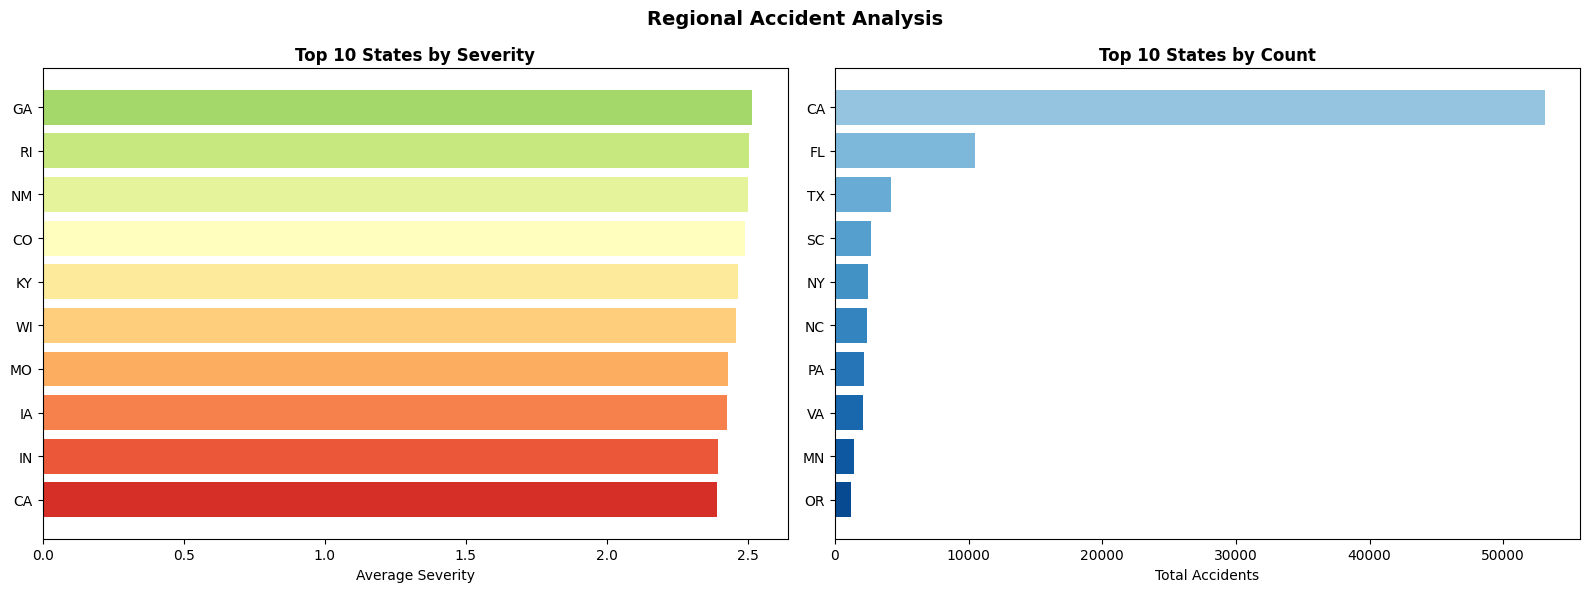



🔬 PER-STATE CAUSE ANALYSIS (Top 3 Dangerous States):

   📍 GA (1196 accidents, avg severity: 2.52):
      Top weather: Fair(336), Mostly Cloudy(173), Clear(171)
      Peak hour: 07:00
      Avg visibility: 9.0 mi
      Avg temperature: 65.4°F

   📍 RI (117 accidents, avg severity: 2.50):
      Top weather: Mostly Cloudy(26), Fair(22), Partly Cloudy(11)
      Peak hour: 08:00
      Avg visibility: 8.5 mi
      Avg temperature: 55.1°F

   📍 NM (64 accidents, avg severity: 2.50):
      Top weather: Fair(19), Partly Cloudy(16), Mostly Cloudy(6)
      Peak hour: 08:00
      Avg visibility: 9.7 mi
      Avg temperature: 58.4°F


🏙️  TOP 10 MOST DANGEROUS CITIES:
───────────────────────────────────────────────────────
    1. Pinole                         Severity: 2.87  Accidents: 55
    2. El Monte                       Severity: 2.87  Accidents: 125
    3. San Clemente                   Severity: 2.87  Accidents: 104
    4. North Hills                    Severity: 2.87  Accidents: 89
   

In [22]:
# Cell 12C: Region-Based Cause Discovery (NEW)
print("="*70)
print("🌎 REGION-BASED ACCIDENT CAUSE DISCOVERY")
print("="*70)
print("Discovering which regions are most dangerous and WHY...\n")

state_col = find_col(df, 'state')
city_col = find_col(df, 'city')
county_col = find_col(df, 'county')

# ─── 1. State-Level Severity Analysis ───
if state_col:
    print("📊 ACCIDENT SEVERITY BY STATE:")
    print("─"*60)

    state_stats = df.groupby(state_col)['Severity'].agg(
        Avg_Severity='mean',
        Total_Accidents='count',
        Severe_Count=lambda x: (x >= 3).sum()
    )
    state_stats['Severe_Pct'] = (
        state_stats['Severe_Count'] / state_stats['Total_Accidents'] * 100
    )
    state_stats = state_stats[state_stats['Total_Accidents'] >= 50]

    # Top 10 most dangerous states
    top_dangerous = state_stats.sort_values('Avg_Severity', ascending=False).head(10)

    print("\n🔴 TOP 10 MOST DANGEROUS STATES (by avg severity):")
    print(f"   {'Rank':<5} {'State':<8} {'Avg Sev':<10} {'Accidents':<12} "
          f"{'Severe %':<10} {'Risk Level'}")
    print("   " + "─"*55)

    for rank, (state, row) in enumerate(top_dangerous.iterrows(), 1):
        if row['Avg_Severity'] >= 2.8:
            risk = "🔴 CRITICAL"
        elif row['Avg_Severity'] >= 2.5:
            risk = "🟠 HIGH"
        elif row['Avg_Severity'] >= 2.2:
            risk = "🟡 MODERATE"
        else:
            risk = "🟢 LOW"
        print(f"   {rank:<5} {str(state):<8} {row['Avg_Severity']:<10.3f} "
              f"{int(row['Total_Accidents']):<12} "
              f"{row['Severe_Pct']:<10.1f} {risk}")

    # Top 10 states by accident COUNT
    top_count = state_stats.sort_values('Total_Accidents', ascending=False).head(10)
    print(f"\n📊 TOP 10 STATES BY ACCIDENT COUNT:")
    for rank, (state, row) in enumerate(top_count.iterrows(), 1):
        bar = "█" * int(row['Total_Accidents'] / top_count['Total_Accidents'].max() * 25)
        print(f"   {rank:2d}. {str(state):<6} "
              f"{int(row['Total_Accidents']):>6} accidents  "
              f"(Severity: {row['Avg_Severity']:.2f})  {bar}")

    # Visualization: Top states comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: by severity
    colors_sev = plt.cm.RdYlGn_r(
        np.linspace(0.3, 0.9, len(top_dangerous))
    )
    axes[0].barh(range(len(top_dangerous)),
                 top_dangerous['Avg_Severity'], color=colors_sev)
    axes[0].set_yticks(range(len(top_dangerous)))
    axes[0].set_yticklabels(top_dangerous.index)
    axes[0].set_xlabel('Average Severity')
    axes[0].set_title('Top 10 States by Severity', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()

    # Right: by count
    colors_cnt = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_count)))
    axes[1].barh(range(len(top_count)),
                 top_count['Total_Accidents'], color=colors_cnt)
    axes[1].set_yticks(range(len(top_count)))
    axes[1].set_yticklabels(top_count.index)
    axes[1].set_xlabel('Total Accidents')
    axes[1].set_title('Top 10 States by Count', fontsize=12, fontweight='bold')
    axes[1].invert_yaxis()

    plt.suptitle('Regional Accident Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ─── 2. Per-State Cause Analysis ───
    print("\n\n🔬 PER-STATE CAUSE ANALYSIS (Top 3 Dangerous States):")
    print("="*60)

    top3_states = top_dangerous.head(3).index.tolist()

    # Check for available analysis columns
    analysis_features = {}
    for col_name, patterns in [
        ('Weather', ['weather_condition', 'weather']),
        ('Visibility', ['visibility']),
        ('Temperature', ['temperature']),
        ('Hour', ['_hour', 'hour']),
    ]:
        found = find_col(df, *patterns)
        if found:
            analysis_features[col_name] = found

    for state in top3_states:
        state_data = df[df[state_col] == state]
        print(f"\n   📍 {state} ({len(state_data)} accidents, "
              f"avg severity: {state_data['Severity'].mean():.2f}):")

        if 'Weather' in analysis_features:
            wcol = analysis_features['Weather']
            top_weather = state_data[wcol].value_counts().head(3)
            print(f"      Top weather: {', '.join([f'{w}({c})' for w, c in top_weather.items()])}")

        if 'Hour' in analysis_features:
            hcol = analysis_features['Hour']
            peak_hour = state_data[hcol].mode().iloc[0] if len(state_data) > 0 else 'N/A'
            print(f"      Peak hour: {int(peak_hour):02d}:00")

        if 'Visibility' in analysis_features:
            vcol = analysis_features['Visibility']
            avg_vis = state_data[vcol].mean()
            print(f"      Avg visibility: {avg_vis:.1f} mi")

        if 'Temperature' in analysis_features:
            tcol = analysis_features['Temperature']
            avg_temp = state_data[tcol].mean()
            print(f"      Avg temperature: {avg_temp:.1f}°F")
else:
    print("⚠️  No state column found in dataset")

# ─── 3. City-Level Hotspots ───
if city_col:
    print("\n\n🏙️  TOP 10 MOST DANGEROUS CITIES:")
    print("─"*55)
    city_stats = df.groupby(city_col)['Severity'].agg(['mean', 'count'])
    city_stats.columns = ['Avg_Severity', 'Count']
    city_stats = city_stats[city_stats['Count'] >= 30]
    city_dangerous = city_stats.sort_values('Avg_Severity', ascending=False).head(10)

    for rank, (city, row) in enumerate(city_dangerous.iterrows(), 1):
        print(f"   {rank:2d}. {str(city):<30} "
              f"Severity: {row['Avg_Severity']:.2f}  "
              f"Accidents: {int(row['Count'])}")

print("\n✅ Region-based cause discovery complete!")

⏰ TEMPORAL PATTERN DISCOVERY
Discovering WHEN accidents are most severe...



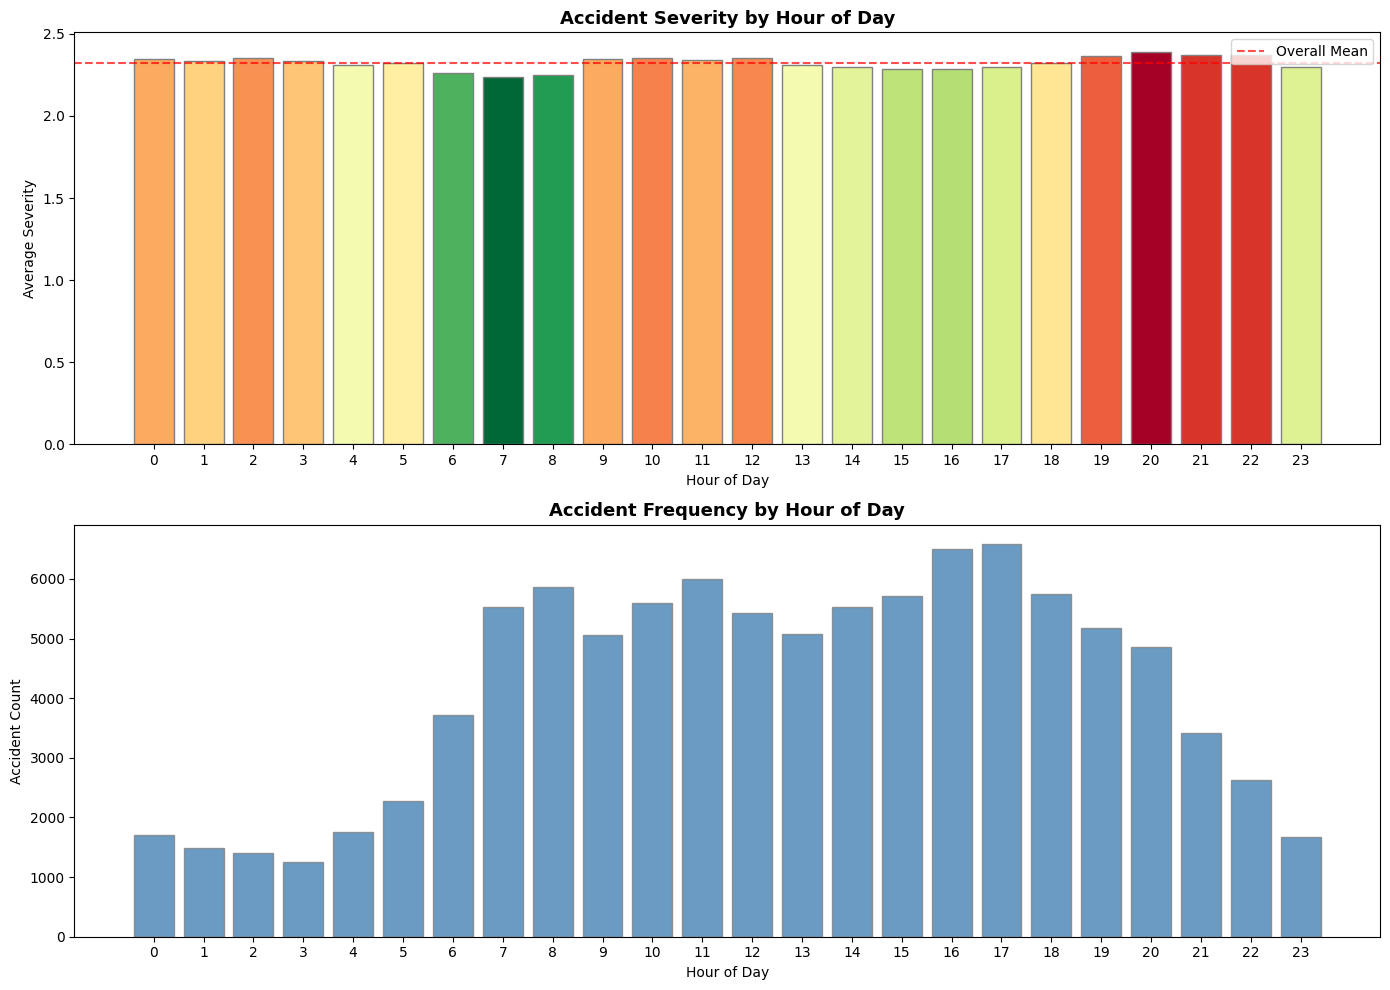

🚗 RUSH HOUR ANALYSIS:
───────────────────────────────────────────────────────
   🟢 Morning Rush (7-9 AM)          Severity: 2.275  (-1.9% vs avg)
   🟡 Midday (10 AM-3 PM)            Severity: 2.325  (+0.3% vs avg)
   🟢 Evening Rush (4-6 PM)          Severity: 2.302  (-0.7% vs avg)
   🟡 Late Night (10 PM-3 AM)        Severity: 2.343  (+1.1% vs avg)
   🟢 Overall Average                Severity: 2.318  (0.0% vs avg)


📅 WEEKDAY vs WEEKEND ANALYSIS:
───────────────────────────────────────────────────────
   Weekday average severity: 2.312
   Weekend average severity: 2.351
   Difference: +1.7%
   → Weekends are MORE dangerous


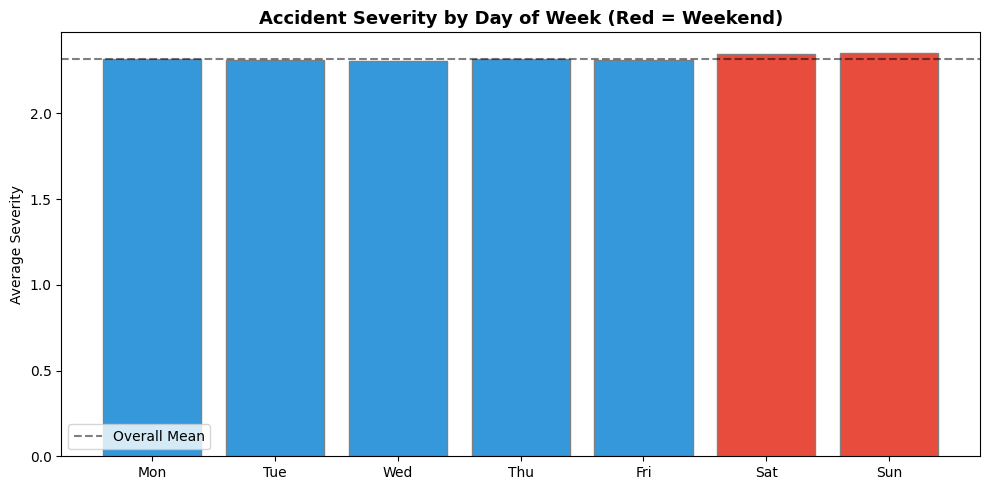



🗓️  HOUR × WEEKDAY SEVERITY HEATMAP:
───────────────────────────────────────────────────────


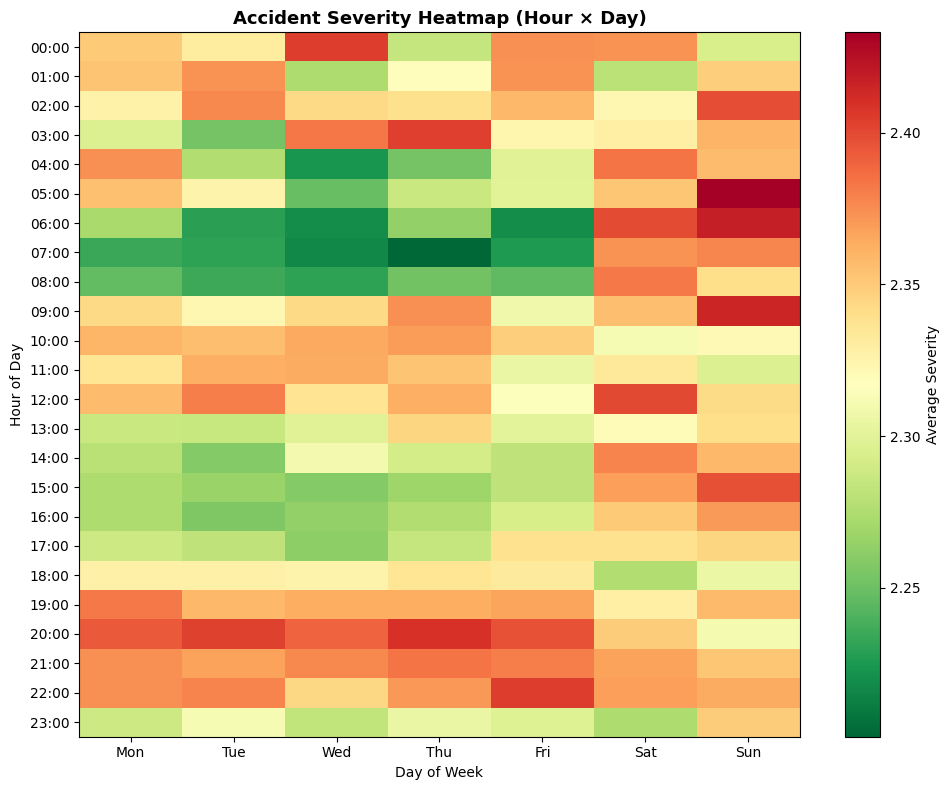

   🔴 TOP 5 MOST DANGEROUS TIME SLOTS:
      1. Sun 05:00 → Severity: 2.433
      2. Sun 06:00 → Severity: 2.418
      3. Sun 09:00 → Severity: 2.415
      4. Thu 20:00 → Severity: 2.409
      5. Fri 22:00 → Severity: 2.405


📆 MONTHLY SEVERITY PATTERN:
───────────────────────────────────────────────────────


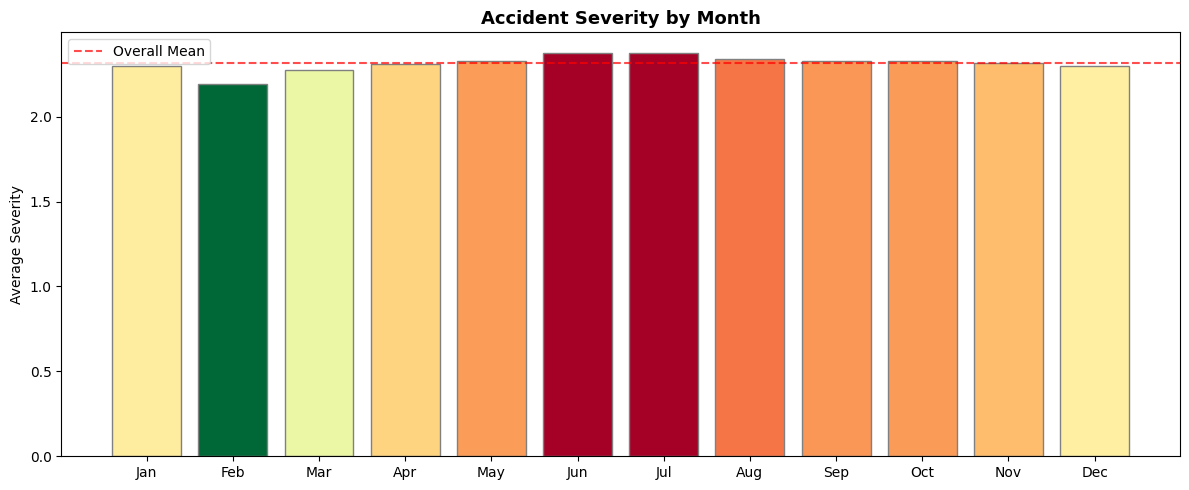

   Most dangerous month:  Jul (Severity: 2.378)
   Safest month:          Feb (Severity: 2.195)

✅ Temporal pattern discovery complete!


In [23]:
# Cell 12D: Temporal Pattern Discovery (NEW)
print("="*70)
print("⏰ TEMPORAL PATTERN DISCOVERY")
print("="*70)
print("Discovering WHEN accidents are most severe...\n")

hour_col = find_col(df, '_hour', 'hour')
weekday_col = find_col(df, 'dayofweek')
month_col = find_col(df, '_month', 'month')

# ─── 1. Hourly Pattern ───
if hour_col:
    hour_stats = df.groupby(hour_col)['Severity'].agg(['mean', 'count'])
    hour_stats.columns = ['Avg_Severity', 'Accident_Count']

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Severity by hour
    colors_h = plt.cm.RdYlGn_r(
        (hour_stats['Avg_Severity'] - hour_stats['Avg_Severity'].min()) /
        (hour_stats['Avg_Severity'].max() - hour_stats['Avg_Severity'].min())
    )
    axes[0].bar(hour_stats.index, hour_stats['Avg_Severity'], color=colors_h, edgecolor='gray')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Average Severity')
    axes[0].set_title('Accident Severity by Hour of Day', fontsize=13, fontweight='bold')
    axes[0].set_xticks(range(0, 24))
    axes[0].axhline(y=hour_stats['Avg_Severity'].mean(), color='red',
                     linestyle='--', alpha=0.7, label='Overall Mean')
    axes[0].legend()

    # Count by hour
    axes[1].bar(hour_stats.index, hour_stats['Accident_Count'],
                color='steelblue', edgecolor='gray', alpha=0.8)
    axes[1].set_xlabel('Hour of Day')
    axes[1].set_ylabel('Accident Count')
    axes[1].set_title('Accident Frequency by Hour of Day', fontsize=13, fontweight='bold')
    axes[1].set_xticks(range(0, 24))

    plt.tight_layout()
    plt.show()

    # Rush hour analysis
    print("🚗 RUSH HOUR ANALYSIS:")
    print("─"*55)
    morning_rush = df[df[hour_col].between(7, 9)]['Severity'].mean()
    evening_rush = df[df[hour_col].between(16, 18)]['Severity'].mean()
    night = df[df[hour_col].isin([22, 23, 0, 1, 2, 3])]['Severity'].mean()
    midday = df[df[hour_col].between(10, 15)]['Severity'].mean()
    overall = df['Severity'].mean()

    periods = [
        ('Morning Rush (7-9 AM)', morning_rush),
        ('Midday (10 AM-3 PM)', midday),
        ('Evening Rush (4-6 PM)', evening_rush),
        ('Late Night (10 PM-3 AM)', night),
        ('Overall Average', overall),
    ]

    for period, sev in periods:
        diff = ((sev - overall) / overall) * 100
        indicator = "🔴" if diff > 2 else ("🟡" if diff > 0 else "🟢")
        print(f"   {indicator} {period:<30} Severity: {sev:.3f}  "
              f"({'+'if diff>0 else ''}{diff:.1f}% vs avg)")

# ─── 2. Day of Week Pattern ───
if weekday_col:
    print(f"\n\n📅 WEEKDAY vs WEEKEND ANALYSIS:")
    print("─"*55)

    day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
    day_stats = df.groupby(weekday_col)['Severity'].agg(['mean', 'count'])
    day_stats.columns = ['Avg_Severity', 'Count']

    weekday_avg = df[df[weekday_col].isin([0,1,2,3,4])]['Severity'].mean()
    weekend_avg = df[df[weekday_col].isin([5,6])]['Severity'].mean()

    print(f"   Weekday average severity: {weekday_avg:.3f}")
    print(f"   Weekend average severity: {weekend_avg:.3f}")
    diff_pct = ((weekend_avg - weekday_avg) / weekday_avg) * 100
    print(f"   Difference: {'+' if diff_pct > 0 else ''}{diff_pct:.1f}%")

    if diff_pct > 0:
        print(f"   → Weekends are MORE dangerous")
    else:
        print(f"   → Weekdays are MORE dangerous")

    # Weekday bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    day_labels = [day_names.get(int(d), str(d)) for d in day_stats.index]
    colors_d = ['#e74c3c' if d in [5, 6] else '#3498db' for d in day_stats.index]
    ax.bar(day_labels, day_stats['Avg_Severity'], color=colors_d, edgecolor='gray')
    ax.set_ylabel('Average Severity')
    ax.set_title('Accident Severity by Day of Week (Red = Weekend)',
                 fontsize=13, fontweight='bold')
    ax.axhline(y=df['Severity'].mean(), color='black',
               linestyle='--', alpha=0.5, label='Overall Mean')
    ax.legend()
    plt.tight_layout()
    plt.show()

# ─── 3. Hour × Weekday Heatmap ───
if hour_col and weekday_col:
    print("\n\n🗓️  HOUR × WEEKDAY SEVERITY HEATMAP:")
    print("─"*55)

    pivot = df.pivot_table(
        values='Severity',
        index=hour_col,
        columns=weekday_col,
        aggfunc='mean'
    )
    pivot.columns = [day_names.get(int(c), str(c)) for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{int(h):02d}:00" for h in pivot.index])
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Hour of Day')
    ax.set_title('Accident Severity Heatmap (Hour × Day)',
                 fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Average Severity')
    plt.tight_layout()
    plt.show()

    # Find the most dangerous time slots
    print("   🔴 TOP 5 MOST DANGEROUS TIME SLOTS:")
    flat_vals = []
    for h in pivot.index:
        for d in pivot.columns:
            flat_vals.append({
                'Hour': f"{int(h):02d}:00",
                'Day': d,
                'Severity': pivot.loc[h, d]
            })

    slots_df = pd.DataFrame(flat_vals).sort_values('Severity', ascending=False)
    for rank, (_, slot) in enumerate(slots_df.head(5).iterrows(), 1):
        print(f"      {rank}. {slot['Day']} {slot['Hour']} → "
              f"Severity: {slot['Severity']:.3f}")

# ─── 4. Monthly Pattern ───
if month_col:
    print(f"\n\n📆 MONTHLY SEVERITY PATTERN:")
    print("─"*55)

    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

    month_stats = df.groupby(month_col)['Severity'].agg(['mean', 'count'])
    month_stats.columns = ['Avg_Severity', 'Count']

    fig, ax = plt.subplots(figsize=(12, 5))
    m_labels = [month_names.get(int(m), str(m)) for m in month_stats.index]
    colors_m = plt.cm.RdYlGn_r(
        (month_stats['Avg_Severity'] - month_stats['Avg_Severity'].min()) /
        (month_stats['Avg_Severity'].max() - month_stats['Avg_Severity'].min() + 1e-8)
    )
    ax.bar(m_labels, month_stats['Avg_Severity'], color=colors_m, edgecolor='gray')
    ax.set_ylabel('Average Severity')
    ax.set_title('Accident Severity by Month', fontsize=13, fontweight='bold')
    ax.axhline(y=df['Severity'].mean(), color='red',
               linestyle='--', alpha=0.7, label='Overall Mean')
    ax.legend()
    plt.tight_layout()
    plt.show()

    worst_month = month_stats['Avg_Severity'].idxmax()
    best_month = month_stats['Avg_Severity'].idxmin()
    print(f"   Most dangerous month:  {month_names.get(int(worst_month), worst_month)} "
          f"(Severity: {month_stats.loc[worst_month, 'Avg_Severity']:.3f})")
    print(f"   Safest month:          {month_names.get(int(best_month), best_month)} "
          f"(Severity: {month_stats.loc[best_month, 'Avg_Severity']:.3f})")

print("\n✅ Temporal pattern discovery complete!")

🗺️  GEOSPATIAL ACCIDENT RISK ANALYSIS
Mapping WHERE accidents happen and WHY they are severe...

   Using 100,000 geolocated accidents
   Lat range: [24.60, 49.00]
   Lng range: [-124.54, -68.80]


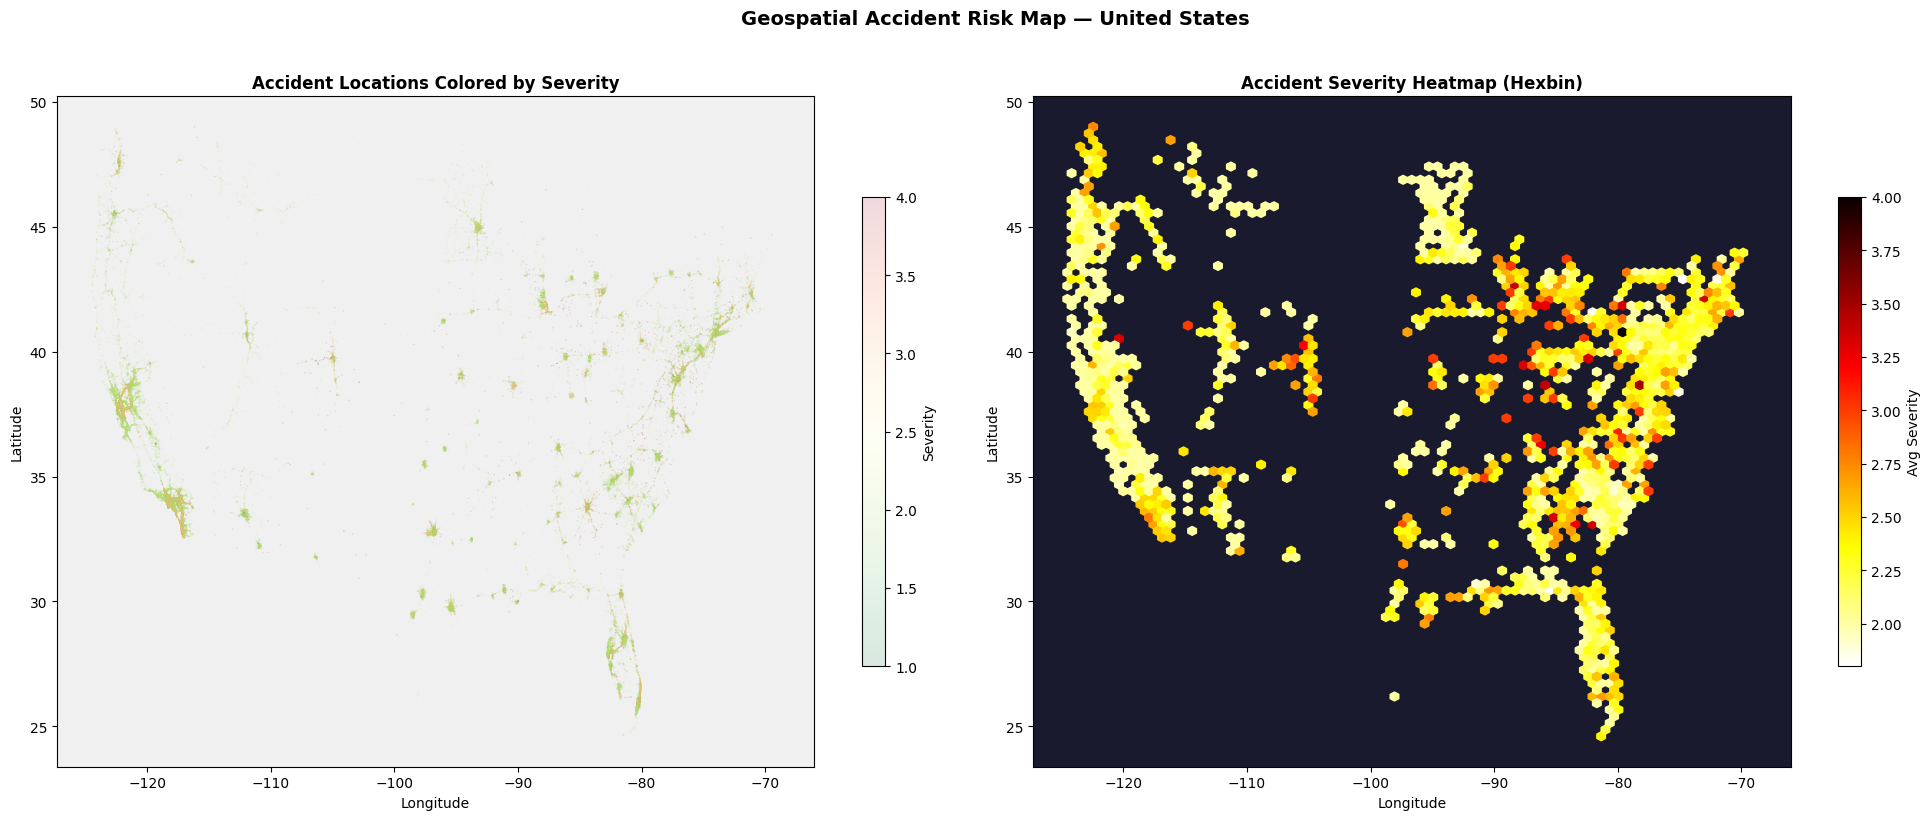


🔬 SHAP-BASED GEOSPATIAL RISK ANALYSIS:
───────────────────────────────────────────────────────


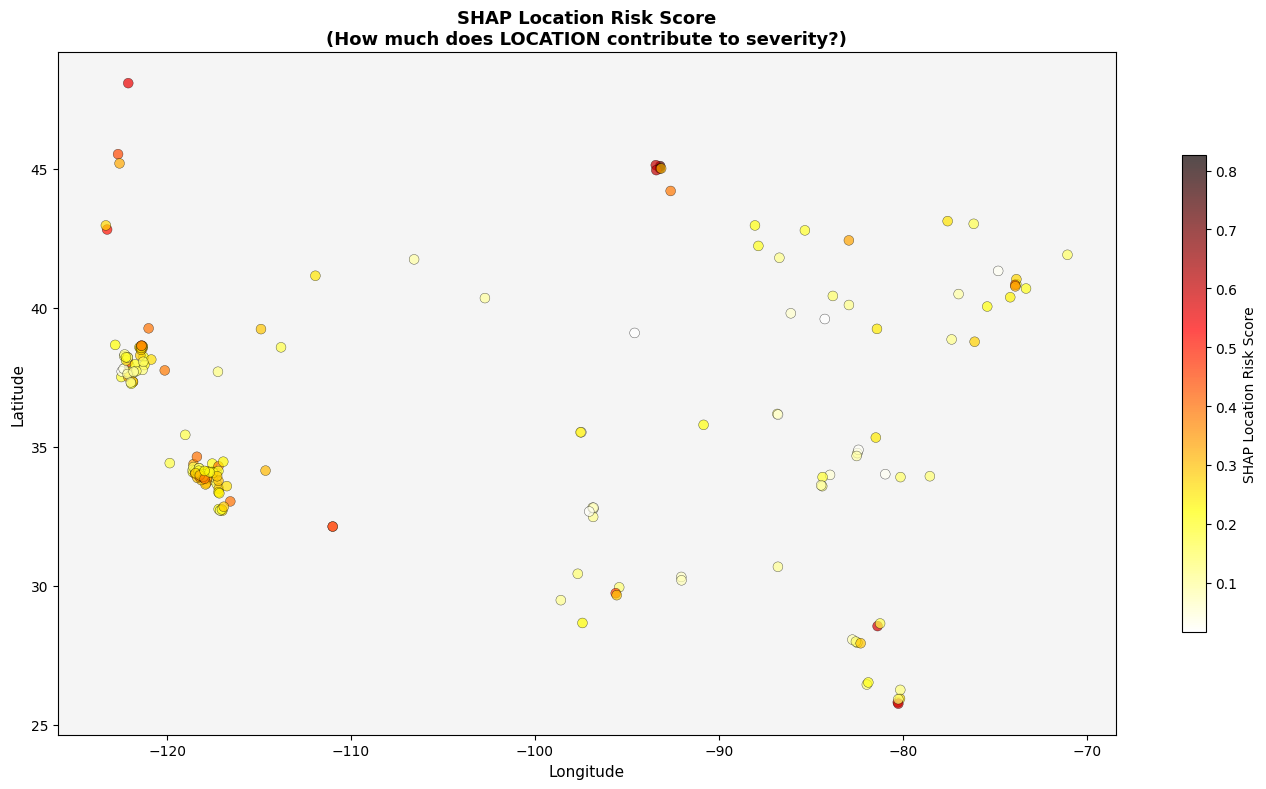


   🔴 HIGH-RISK GEOGRAPHIC ZONES:
      Lat range: [25.76, 48.08]
      Lng range: [-123.26, -73.88]
      40 high-risk locations identified

      Top states in high-risk zones:
         CA: 22 locations
         MN: 6 locations
         OR: 3 locations
         FL: 3 locations
         NY: 2 locations


📊 REGIONAL SEVERITY BREAKDOWN:
───────────────────────────────────────────────────────


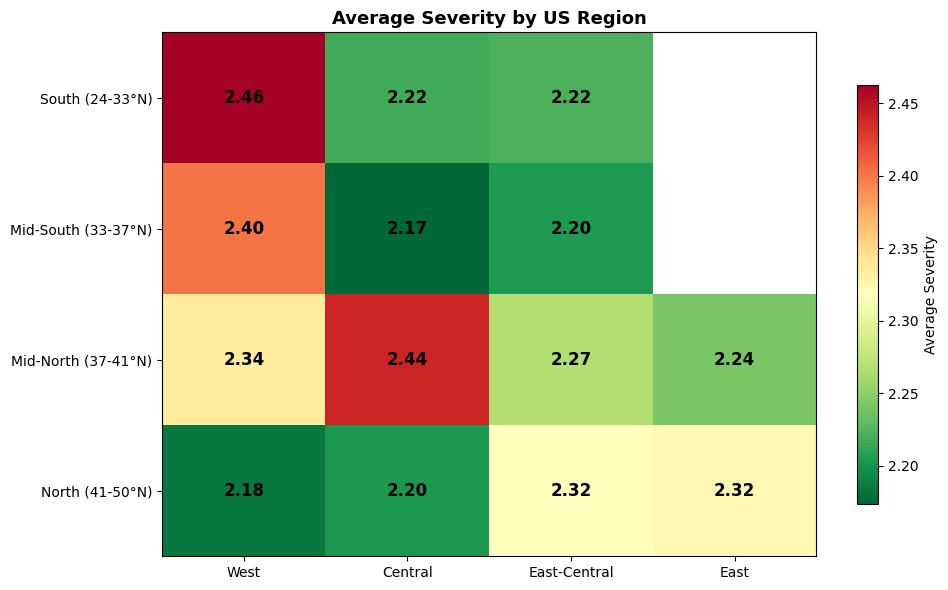


✅ Geospatial risk analysis complete!


In [24]:
# Cell 12E: Geospatial SHAP Risk Heatmap (NEW - NOVEL)
print("="*70)
print("🗺️  GEOSPATIAL ACCIDENT RISK ANALYSIS")
print("="*70)
print("Mapping WHERE accidents happen and WHY they are severe...\n")

lat_col = find_col(df, 'start_lat', 'lat')
lng_col = find_col(df, 'start_lng', 'lng', 'start_lon', 'lon')

if lat_col and lng_col:
    # Filter to continental US bounds
    geo_df = df[
        (df[lat_col].between(24, 50)) &
        (df[lng_col].between(-125, -66))
    ].copy()

    print(f"   Using {len(geo_df):,} geolocated accidents")
    print(f"   Lat range: [{geo_df[lat_col].min():.2f}, {geo_df[lat_col].max():.2f}]")
    print(f"   Lng range: [{geo_df[lng_col].min():.2f}, {geo_df[lng_col].max():.2f}]")

    # ─── Plot 1: Accident Density + Severity Scatter ───
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Left: All accidents colored by severity
    scatter = axes[0].scatter(
        geo_df[lng_col], geo_df[lat_col],
        c=geo_df['Severity'], cmap='RdYlGn_r',
        alpha=0.15, s=1, edgecolors='none'
    )
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].set_title('Accident Locations Colored by Severity',
                       fontsize=12, fontweight='bold')
    axes[0].set_facecolor('#f0f0f0')
    plt.colorbar(scatter, ax=axes[0], label='Severity', shrink=0.7)

    # Right: Hexbin density heatmap
    hb = axes[1].hexbin(
        geo_df[lng_col], geo_df[lat_col],
        C=geo_df['Severity'], gridsize=80,
        cmap='hot_r', reduce_C_function=np.mean,
        mincnt=3
    )
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title('Accident Severity Heatmap (Hexbin)',
                       fontsize=12, fontweight='bold')
    axes[1].set_facecolor('#1a1a2e')
    plt.colorbar(hb, ax=axes[1], label='Avg Severity', shrink=0.7)

    plt.suptitle('Geospatial Accident Risk Map — United States',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ─── Plot 2: SHAP-Based Location Risk Analysis ───
    print("\n🔬 SHAP-BASED GEOSPATIAL RISK ANALYSIS:")
    print("─"*55)

    # Find lat/lng columns in feature set
    lat_feat = find_col(X, 'start_lat', 'lat')
    lng_feat = find_col(X, 'start_lng', 'lng', 'start_lon', 'lon')

    if lat_feat and lng_feat:
        lat_feat_idx = X.columns.tolist().index(lat_feat)
        lng_feat_idx = X.columns.tolist().index(lng_feat)

        # Get SHAP values for lat and lng
        if isinstance(shap_values, list):
            shap_lat = np.abs(shap_values[-1][:, lat_feat_idx])  # Highest severity class
            shap_lng = np.abs(shap_values[-1][:, lng_feat_idx])
        elif len(shap_values.shape) == 3:
            shap_lat = np.abs(shap_values[:, lat_feat_idx, -1])
            shap_lng = np.abs(shap_values[:, lng_feat_idx, -1])
        else:
            shap_lat = np.abs(shap_values[:, lat_feat_idx])
            shap_lng = np.abs(shap_values[:, lng_feat_idx])

        # Combined location risk score
        location_risk = shap_lat + shap_lng

        # Get lat/lng values from X_shap
        shap_lats = X_shap[lat_feat].values
        shap_lngs = X_shap[lng_feat].values

        # Filter to valid US bounds
        valid = (
            (shap_lats > 24) & (shap_lats < 50) &
            (shap_lngs > -125) & (shap_lngs < -66)
        )

        if valid.sum() > 10:
            fig, ax = plt.subplots(figsize=(14, 8))
            scatter = ax.scatter(
                shap_lngs[valid], shap_lats[valid],
                c=location_risk[valid],
                cmap='hot_r', s=50, alpha=0.7,
                edgecolors='black', linewidth=0.3
            )
            ax.set_xlabel('Longitude', fontsize=11)
            ax.set_ylabel('Latitude', fontsize=11)
            ax.set_title('SHAP Location Risk Score\n'
                         '(How much does LOCATION contribute to severity?)',
                         fontsize=13, fontweight='bold')
            ax.set_facecolor('#f5f5f5')
            plt.colorbar(scatter, ax=ax, label='SHAP Location Risk Score', shrink=0.7)
            plt.tight_layout()
            plt.show()

            # Identify high-risk zones
            print("\n   🔴 HIGH-RISK GEOGRAPHIC ZONES:")
            risk_threshold = np.percentile(location_risk[valid], 80)
            high_risk_mask = valid & (location_risk >= risk_threshold)

            if high_risk_mask.sum() > 0:
                hr_lats = shap_lats[high_risk_mask]
                hr_lngs = shap_lngs[high_risk_mask]
                print(f"      Lat range: [{hr_lats.min():.2f}, {hr_lats.max():.2f}]")
                print(f"      Lng range: [{hr_lngs.min():.2f}, {hr_lngs.max():.2f}]")
                print(f"      {high_risk_mask.sum()} high-risk locations identified")

                # Match to states if possible
                if state_col and state_col in df.columns:
                    hr_indices = X_shap.index[high_risk_mask]
                    valid_indices = [i for i in hr_indices if i in df.index]
                    if valid_indices:
                        hr_states = df.loc[valid_indices, state_col].value_counts().head(5)
                        print(f"\n      Top states in high-risk zones:")
                        for st, cnt in hr_states.items():
                            print(f"         {st}: {cnt} locations")
        else:
            print("   ⚠️  Not enough valid coordinates for SHAP map")
    else:
        print("   ⚠️  Lat/Lng features not found in model features")

    # ─── Plot 3: Regional Severity Comparison ───
    print("\n\n📊 REGIONAL SEVERITY BREAKDOWN:")
    print("─"*55)

    geo_df['_lat_zone'] = pd.cut(
        geo_df[lat_col],
        bins=[24, 33, 37, 41, 50],
        labels=['South (24-33°N)', 'Mid-South (33-37°N)',
                'Mid-North (37-41°N)', 'North (41-50°N)']
    )
    geo_df['_lng_zone'] = pd.cut(
        geo_df[lng_col],
        bins=[-125, -105, -90, -75, -66],
        labels=['West', 'Central', 'East-Central', 'East']
    )

    if '_lat_zone' in geo_df.columns and '_lng_zone' in geo_df.columns:
        region_pivot = geo_df.pivot_table(
            values='Severity',
            index='_lat_zone',
            columns='_lng_zone',
            aggfunc='mean'
        )

        if not region_pivot.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            im = ax.imshow(region_pivot.values, cmap='RdYlGn_r',
                           aspect='auto', interpolation='nearest')
            ax.set_xticks(range(len(region_pivot.columns)))
            ax.set_xticklabels(region_pivot.columns, fontsize=10)
            ax.set_yticks(range(len(region_pivot.index)))
            ax.set_yticklabels(region_pivot.index, fontsize=10)

            # Add text annotations
            for i in range(len(region_pivot.index)):
                for j in range(len(region_pivot.columns)):
                    val = region_pivot.iloc[i, j]
                    if not np.isnan(val):
                        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                                fontsize=12, fontweight='bold',
                                color='white' if val > 2.5 else 'black')

            ax.set_title('Average Severity by US Region',
                         fontsize=13, fontweight='bold')
            plt.colorbar(im, ax=ax, label='Average Severity', shrink=0.8)
            plt.tight_layout()
            plt.show()

    # Clean up
    for tmp in ['_lat_zone', '_lng_zone']:
        if tmp in geo_df.columns:
            geo_df.drop(columns=[tmp], inplace=True)

else:
    print("⚠️  No latitude/longitude columns found in dataset")
    print("   Geospatial analysis requires Start_Lat and Start_Lng columns")

print("\n✅ Geospatial risk analysis complete!")

In [25]:
# Cell 13: Manual Prediction Function (Updated for Best Model)
print("="*70)
print("MANUAL PREDICTION FUNCTION")
print("="*70)

# Helper to safely extract a single base value
def get_base_value(expected_value, class_idx=0):
    """Extract a single float base value from any expected_value format."""
    if isinstance(expected_value, (list, np.ndarray)):
        return float(expected_value[class_idx])
    else:
        return float(expected_value)

def predict_accident_severity(input_dict, show_explanation=True):
    """
    Predict accident severity using the best model (XGBoost or DT)
    Handles both RAW and ENCODED inputs
    """
    input_df = pd.DataFrame([input_dict])

    # Handle categorical encoding for raw string inputs
    for col in label_encoders:
        if col in input_df.columns:
            val = input_df[col].iloc[0]
            if pd.api.types.is_numeric_dtype(type(val)):
                continue
            try:
                if str(val) in label_encoders[col].classes_:
                    input_df[col] = label_encoders[col].transform([str(val)])
                else:
                    print(f"⚠️  Unknown '{val}' for {col}, using 0")
                    input_df[col] = 0
            except:
                input_df[col] = 0

    # Ensure all features present
    for col in X.columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[X.columns].astype(float)

    # Predict
    prediction_raw = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0]

    # Map back if using XGBoost remapped labels
    if use_xgb_labels:
        pred_class = int(class_map_inv.get(prediction_raw, prediction_raw))
    else:
        pred_class = int(prediction_raw)

    print("\n" + "="*70)
    print(f"🎯 PREDICTION RESULT (using {best_model_name})")
    print("="*70)

    if target_encoder is not None:
        pred_label = target_encoder.inverse_transform([pred_class])[0]
        print(f"\n✨ Predicted Severity: {pred_label} (class {pred_class})")
        print(f"\n📊 Confidence Scores:")
        for i, prob in enumerate(probability):
            bar = "█" * int(prob * 40)
            cls_orig = class_map_inv.get(i, i) if use_xgb_labels else i
            class_label = target_encoder.classes_[cls_orig]
            print(f"   {class_label:<15}: {prob:.4f} ({prob*100:5.2f}%) [{bar}]")
    else:
        print(f"\n✨ Predicted Severity: {pred_class}")
        print(f"\n📊 Confidence Scores:")
        for i, prob in enumerate(probability):
            bar = "█" * int(prob * 40)
            cls_orig = class_map_inv.get(i, i) if use_xgb_labels else i
            print(f"   Class {cls_orig:<10}: {prob:.4f} ({prob*100:5.2f}%) [{bar}]")

    # SHAP explanation
    if show_explanation:
        try:
            shap_vals = explainer.shap_values(input_df)

            print("\n" + "="*70)
            print("📈 SHAP EXPLANATION")
            print("="*70)

            pred_idx = int(prediction_raw)

            if isinstance(shap_vals, list):
                # List of arrays: one per class
                sv = shap_vals[pred_idx][0]
                bv = get_base_value(explainer.expected_value, pred_idx)

            elif isinstance(shap_vals, np.ndarray) and len(shap_vals.shape) == 3:
                # 3D array: (n_samples, n_features, n_classes)
                sv = shap_vals[0, :, pred_idx]
                bv = get_base_value(explainer.expected_value, pred_idx)

            else:
                # 2D array: binary or regression
                sv = shap_vals[0]
                if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
                    bv = get_base_value(explainer.expected_value, 1)
                else:
                    bv = get_base_value(explainer.expected_value)

            shap.waterfall_plot(
                shap.Explanation(
                    values=sv,
                    base_values=bv,
                    data=input_df.iloc[0].values,
                    feature_names=X.columns.tolist()
                )
            )
        except Exception as e:
            print(f"⚠️  SHAP explanation error: {e}")

    return pred_class, probability

print(f"✅ Prediction function ready (using {best_model_name})!")

MANUAL PREDICTION FUNCTION
✅ Prediction function ready (using XGBoost)!


EXAMPLE PREDICTION
📝 Sample Input (first 10 features):
    1. Source                   : 1.0
    2. Start_Lat                : 39.747753
    3. Start_Lng                : -84.20558199999998
    4. Distance(mi)             : 0.0
    5. Street                   : 15162.0
    6. City                     : 1142.0
    7. County                   : 682.0
    8. State                    : 33.0
    9. Zipcode                  : 12953.0
   10. Country                  : 0.0

🚀 Predicting...

🎯 PREDICTION RESULT (using XGBoost)

✨ Predicted Severity: 3

📊 Confidence Scores:
   Class 1         : 0.0001 ( 0.01%) []
   Class 2         : 0.1270 (12.70%) [█████]
   Class 3         : 0.8726 (87.26%) [██████████████████████████████████]
   Class 4         : 0.0003 ( 0.03%) []

📈 SHAP EXPLANATION


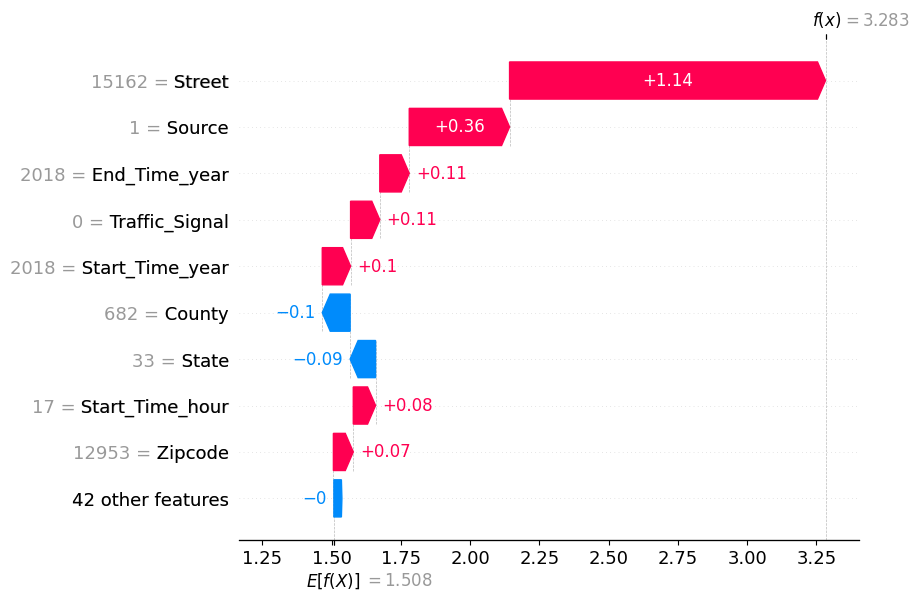


✅ Example completed successfully!


In [26]:
# Cell 14: Example Prediction
print("="*70)
print("EXAMPLE PREDICTION")
print("="*70)

example_input = X_test.iloc[0].to_dict()

print("📝 Sample Input (first 10 features):")
for i, (key, value) in enumerate(list(example_input.items())[:10]):
    print(f"   {i+1:2d}. {key:<25}: {value}")

print("\n🚀 Predicting...")
prediction, probability = predict_accident_severity(example_input, show_explanation=True)
print("\n✅ Example completed successfully!")

In [27]:
# Cell 15: Feature Reference Guide
print("="*70)
print("📋 FEATURE REFERENCE GUIDE")
print("="*70)
print(f"\nTotal features: {len(X.columns)}\n")

for i, col in enumerate(X.columns[:20], 1):
    print(f"{i}. {col}")
    print(f"   {'─'*60}")
    if col in categorical_cols:
        unique_vals = df[col].unique() if col in df.columns else ['N/A']
        print(f"   Type: Categorical")
        print(f"   Sample values: {list(unique_vals[:5])}")
    else:
        if col in df.columns:
            print(f"   Type: Numeric")
            print(f"   Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
            print(f"   Mean: {df[col].mean():.2f}")
        else:
            print(f"   Type: Derived Feature")
    print()

if len(X.columns) > 20:
    print(f"... and {len(X.columns) - 20} more features")

📋 FEATURE REFERENCE GUIDE

Total features: 51

1. Source
   ────────────────────────────────────────────────────────────
   Type: Categorical
   Sample values: ['Source2', 'Source1', 'Source3']

2. Start_Lat
   ────────────────────────────────────────────────────────────
   Type: Numeric
   Range: [24.60, 49.00]
   Mean: 35.51

3. Start_Lng
   ────────────────────────────────────────────────────────────
   Type: Numeric
   Range: [-124.54, -68.80]
   Mean: -104.18

4. Distance(mi)
   ────────────────────────────────────────────────────────────
   Type: Numeric
   Range: [0.00, 74.10]
   Mean: 0.32

5. Street
   ────────────────────────────────────────────────────────────
   Type: Categorical
   Sample values: ['W Manchester Ave', 'NW 79th Ave', 'Foothill Rd', 'Keller Springs Rd', 'N Fant St']

6. City
   ────────────────────────────────────────────────────────────
   Type: Categorical
   Sample values: ['Los Angeles', 'Miami', 'Pleasanton', 'Carrollton', 'Anderson']

7. County
   ─────

In [28]:
# Cell 16: Final Summary (UPDATED)
print("="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║          EXPLAINABLE ACCIDENT CAUSE DISCOVERY SYSTEM               ║
╚══════════════════════════════════════════════════════════════════════╝

📊 MODEL SUMMARY:
   • Dataset: US Accidents (Kaggle, ~3GB)
   • Samples used: {len(df):,}
   • Features: {X.shape[1]}
   • Target: Accident Severity (1-4)

🏆 MODEL COMPARISON:
   ┌──────────────────┬────────────────┬───────────────┐
   │ Model            │ Train Accuracy │ Test Accuracy │
   ├──────────────────┼────────────────┼───────────────┤
   │ Decision Tree    │ {dt_train_acc*100:>12.2f}% │ {dt_test_acc*100:>11.2f}% │
   │ XGBoost          │ {xgb_train_acc*100:>12.2f}% │ {xgb_test_acc*100:>11.2f}% │
   └──────────────────┴────────────────┴───────────────┘
   Best Model: {best_model_name} ({best_test_acc*100:.2f}%)

🔝 TOP 5 ACCIDENT FACTORS:
{feature_importance_df.head(5).to_string(index=False)}
""")

# Print interactions if available
print("🔗 KEY FEATURE INTERACTIONS:")
try:
    for _, row in interact_df.head(3).iterrows():
        print(f"   • {row['Feature_1']} × {row['Feature_2']} "
              f"(strength: {row['Interaction_Strength']:.4f})")
except:
    print("   • (Interaction data not available)")

print(f"""
📦 SYSTEM CAPABILITIES:
   ✓ Accident severity prediction (Decision Tree + XGBoost)
   ✓ SHAP global feature importance
   ✓ SHAP individual prediction explanation (waterfall)
   ✓ Feature interaction discovery (SHAP interactions)
   ✓ Context-based cause analysis (weather + time + day combos)
   ✓ Region-based cause discovery (state/city risk analysis)
   ✓ Temporal pattern discovery (hour/day/month patterns)
   ✓ Geospatial SHAP risk heatmap (location-based risk)

🏗️  ARCHITECTURE:
   US Accidents Dataset (3GB)
        │
   DuckDB Sampling (100K rows)
        │
   Preprocessing (auto-encode, datetime features)
        │
   ┌─────────────┬─────────────┐
   │ Decision Tree│   XGBoost   │
   │  (Baseline)  │  (Primary)  │
   └──────┬──────┴──────┬──────┘
          │             │
          └──── SHAP TreeExplainer ────┘
                        │
          ┌─────────────┼─────────────┐
          │             │             │
    Global Feature  Individual   Interaction
    Importance      Waterfall    Analysis
          │             │             │
          └─────────────┼─────────────┘
                        │
     ┌──────────────────┼──────────────────┐
     │                  │                  │
  Context-Based    Region-Based     Geospatial
  Cause Analysis   Risk Discovery   Risk Heatmap
  (weather+time)   (state/city)     (lat/lng SHAP)

📦 AVAILABLE FUNCTION:
   predict_accident_severity(input_dict, show_explanation=True)

💡 This system goes beyond prediction to EXPLAIN and DISCOVER
   the underlying causes of traffic accidents.
""")

✅ ANALYSIS COMPLETE!

╔══════════════════════════════════════════════════════════════════════╗
║          EXPLAINABLE ACCIDENT CAUSE DISCOVERY SYSTEM               ║
╚══════════════════════════════════════════════════════════════════════╝

📊 MODEL SUMMARY:
   • Dataset: US Accidents (Kaggle, ~3GB)
   • Samples used: 100,000
   • Features: 51
   • Target: Accident Severity (1-4)

🏆 MODEL COMPARISON:
   ┌──────────────────┬────────────────┬───────────────┐
   │ Model            │ Train Accuracy │ Test Accuracy │
   ├──────────────────┼────────────────┼───────────────┤
   │ Decision Tree    │        88.40% │       87.39% │
   │ XGBoost          │        95.99% │       90.49% │
   └──────────────────┴────────────────┴───────────────┘
   Best Model: XGBoost (90.49%)

🔝 TOP 5 ACCIDENT FACTORS:
        Feature  Importance
   Distance(mi)    0.564405
         Source    0.505403
         Street    0.372870
Start_Time_year    0.336842
  End_Time_year    0.203361

🔗 KEY FEATURE INTERACTIONS:
   •